In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# DL 모델
from tensorflow.keras import Sequential
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import LSTM, Dropout, Dense

import tensorflow as tf
tf.random.set_seed(42)
np.random.seed(42)
import random; random.seed(42)

import warnings
warnings.filterwarnings('ignore')

sns.set()

# 차트 한글 처리
import platform
def set_korean_font():
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif platform.system() == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>1. 데이터 읽어오기

## <b>1-1. 데이터 로드

In [2]:
"""
Delhi 일별 기후 데이터 — 딥러닝 시계열 분석
대상 파일: DailyDelhiClimateTrain.csv / DailyDelhiClimateTest.csv
컬럼: date, meantemp, humidity, wind_speed, meanpressure
목표: meantemp (평균 기온) 예측
"""

# ============================================================
# 1-1. 데이터 로드
# ============================================================
df_train = pd.read_csv('dataset\DailyDelhiClimate\DailyDelhiClimateTrain.csv')
df_test  = pd.read_csv('dataset\DailyDelhiClimate\DailyDelhiClimateTest.csv')

print("=" * 60)
print("1-1. 데이터 로드")
print("=" * 60)
print(f"Train 로드 완료: {df_train.shape[0]}행 × {df_train.shape[1]}열")
print(f"Test  로드 완료: {df_test.shape[0]}행 × {df_test.shape[1]}열\n")

1-1. 데이터 로드
Train 로드 완료: 1462행 × 5열
Test  로드 완료: 114행 × 5열



## <b>1-2. 기본 구조 확인

In [3]:
# ============================================================
# 1-2. 기본 구조 확인
# ============================================================

print("=" * 60)                      
print("1-2. 기본 구조 확인 (Train)") 
print("=" * 60)                      

print("[컬럼 목록]")                  
print(df_train.columns.tolist())     # 모든 컬럼명을 리스트로 출력

print("\n[데이터 타입]")              
print(df_train.dtypes)               # 각 컬럼의 타입 출력 (int64, object 등)

print("\n[처음 3행]")                 
print(df_train.head(3))              # 상위 3행 출력 (기본값은 5행)

print("\n[마지막 3행]")               
print(df_train.tail(3))              # 하위 3행 출력

print("\n" + "=" * 60)               
print("기본 구조 확인 (Test)")        # Test 섹션 제목 출력
print("=" * 60)                      

print(df_test.head(3))               # Test 데이터 상위 3행 출력

1-2. 기본 구조 확인 (Train)
[컬럼 목록]
['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

[데이터 타입]
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

[처음 3행]
         date   meantemp  humidity  wind_speed  meanpressure
0  2013-01-01  10.000000      84.5    0.000000   1015.666667
1  2013-01-02   7.400000      92.0    2.980000   1017.800000
2  2013-01-03   7.166667      87.0    4.633333   1018.666667

[마지막 3행]
            date   meantemp    humidity  wind_speed  meanpressure
1459  2016-12-30  14.095238   89.666667    6.266667   1017.904762
1460  2016-12-31  15.052632   87.000000    7.325000   1016.100000
1461  2017-01-01  10.000000  100.000000    0.000000   1016.000000

기본 구조 확인 (Test)
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.8888

## <b>1-3. date 컬럼 타입 변환

In [4]:
# ============================================================
# 1-3. date 컬럼 타입 변환 및 정렬
# ============================================================

print("\n" + "=" * 60)                              
print("1-3. date 컬럼 타입 변환 및 정렬")           
print("=" * 60)                                     

for name, df in [('Train', df_train), ('Test', df_test)]:      # 두 데이터프레임을 순서대로 순회
    print(f"[{name}]")                                         # Train / Test 레이블 출력
    print(f"  변환 전 타입: {df['date'].dtype}")                # 변환 전 타입 확인 (보통 object)

df_train['date'] = pd.to_datetime(df_train['date'])            # date 컬럼을 datetime64 타입으로 변환
df_test['date']  = pd.to_datetime(df_test['date'])             # 동일하게 Test도 변환

df_train = df_train.sort_values('date').reset_index(drop=True) # 날짜 오름차순 정렬 후 인덱스 재설정
df_test  = df_test.sort_values('date').reset_index(drop=True)  # 동일하게 Test도 정렬

print(f"Train 변환 후: {df_train['date'].dtype}  |  "           # 변환된 타입 출력
      f"범위: {df_train['date'].min().date()} ~ "               # 가장 이른 날짜 출력
      f"{df_train['date'].max().date()}  |  "                   # 가장 늦은 날짜 출력
      f"{len(df_train)}일")                                     # 전체 행 수(일 수) 출력

print(f"Test  변환 후: {df_test['date'].dtype}   |  "           # 동일 구조로 Test 정보 출력
      f"범위: {df_test['date'].min().date()} ~ "
      f"{df_test['date'].max().date()}   |  "
      f"{len(df_test)}일")


1-3. date 컬럼 타입 변환 및 정렬
[Train]
  변환 전 타입: object
[Test]
  변환 전 타입: object
Train 변환 후: datetime64[ns]  |  범위: 2013-01-01 ~ 2017-01-01  |  1462일
Test  변환 후: datetime64[ns]   |  범위: 2017-01-01 ~ 2017-04-24   |  114일


## <b>1-4. 결측치 확인

In [5]:
# ============================================================
# 1-4. 결측치 확인
# ============================================================

print("\n" + "=" * 60)               
print("1-4. 결측치 확인")             
print("=" * 60)                      

for name, df in [('Train', df_train), ('Test', df_test)]:  # 두 데이터프레임 순회
    missing = df.isnull().sum()                            # 각 컬럼별 결측치 개수 합산
    missing_pct = (missing / len(df) * 100).round(4)       # 결측치 비율(%) 계산, 소수점 4자리
    missing_df = pd.DataFrame({                            # 결측 수 + 결측률을 하나의 DataFrame으로 합치기
        '결측 수': missing,
        '결측률(%)': missing_pct
    })
    print(f"\n[{name}]")                         # Train / Test 레이블 출력
    print(missing_df)                            # 컬럼별 결측 현황 테이블 출력
    print(f"전체 결측치 합계: {missing.sum()}개") # 모든 컬럼 결측치를 하나의 숫자로 합산 출력

    if missing.sum() > 0:                        # 결측치가 1개 이상일 때만 아래 블록 실행
        print("[결측치 포함 행 상세]")
        print(df[df.isnull().any(axis=1)])       # 한 컬럼이라도 결측인 행 전체 출력
                                                 # axis=1 → 행 방향으로 검사


1-4. 결측치 확인

[Train]
              결측 수  결측률(%)
date             0     0.0
meantemp         0     0.0
humidity         0     0.0
wind_speed       0     0.0
meanpressure     0     0.0
전체 결측치 합계: 0개

[Test]
              결측 수  결측률(%)
date             0     0.0
meantemp         0     0.0
humidity         0     0.0
wind_speed       0     0.0
meanpressure     0     0.0
전체 결측치 합계: 0개


## <b>1-5. 중복 확인

In [6]:
# ============================================================
# 1-5. 중복 확인
# ============================================================
# 중복 행이 있으면 모델이 특정 날짜 패턴을 과대학습할 수 있고,
# 날짜 중복은 시계열 분석의 전제(1일 1행)를 깨뜨리므로 반드시 확인

print("\n" + "=" * 60)
print("1-5. 중복 확인")
print("=" * 60)

for name, df in [('Train', df_train), ('Test', df_test)]:  # 두 데이터프레임 순회
    dup_rows  = df.duplicated().sum()                      # 모든 컬럼이 동일한 중복 행 개수
                                                           # → 완전히 똑같은 행이 두 번 들어간 경우 탐지
    dup_dates = df['date'].duplicated().sum()              # date 컬럼만 기준으로 중복 날짜 개수
                                                           # → 같은 날짜가 두 행으로 나뉜 경우 탐지
    print(f"[{name}]  중복 행: {dup_rows}개  |  날짜 중복: {dup_dates}개")

    if dup_rows > 0:                            # 중복 행이 있을 때만 실행
        print(df[df.duplicated(keep=False)])    # keep=False → 중복에 관여된 모든 행 출력
                                                # (기본값 keep='first'는 첫 번째 행만 제외)


1-5. 중복 확인
[Train]  중복 행: 0개  |  날짜 중복: 0개
[Test]  중복 행: 0개  |  날짜 중복: 0개


## <b>1-6. 기술 통계

In [7]:
# ============================================================
# 1-6. 기술 통계
# ============================================================
# 평균·표준편차·최솟값·최댓값 등을 한눈에 확인해
# 이상치 존재 여부와 데이터 분포를 빠르게 파악

print("\n" + "=" * 60)
print("1-6. 기술 통계 (Train)")
print("=" * 60)
print(df_train.describe().round(2))  # count·mean·std·min·25%·50%·75%·max 출력, 소수점 2자리

print("\n" + "=" * 60)
print("기술 통계 (Test)")
print("=" * 60)
print(df_test.describe().round(2))   # Train과 동일 구조로 Test 기술 통계 출력


1-6. 기술 통계 (Train)
                      date  meantemp  humidity  wind_speed  meanpressure
count                 1462   1462.00   1462.00     1462.00       1462.00
mean   2015-01-01 12:00:00     25.50     60.77        6.80       1011.10
min    2013-01-01 00:00:00      6.00     13.43        0.00         -3.04
25%    2014-01-01 06:00:00     18.86     50.38        3.48       1001.58
50%    2015-01-01 12:00:00     27.71     62.62        6.22       1008.56
75%    2016-01-01 18:00:00     31.31     72.22        9.24       1014.94
max    2017-01-01 00:00:00     38.71    100.00       42.22       7679.33
std                    NaN      7.35     16.77        4.56        180.23

기술 통계 (Test)
                      date  meantemp  humidity  wind_speed  meanpressure
count                  114    114.00    114.00      114.00        114.00
mean   2017-02-26 12:00:00     21.71     56.26        8.14       1004.04
min    2017-01-01 00:00:00     11.00     17.75        1.39         59.00
25%    2017-01-29

## <b>1-7. 날짜 연속성 확인 (gap 분석)

In [8]:
# ============================================================
# 1-7. 날짜 연속성 확인 (Date Gap)
#    - 날씨 데이터는 매일(주말 포함) 기록 → 1일 간격이 정상
# ============================================================
# 날짜가 하루씩 빠짐없이 이어지는지 확인
# 공백이 있으면 시계열 모델이 잘못된 패턴을 학습할 수 있음

print("\n" + "=" * 60)
print("1-7. 날짜 연속성 확인 (Date Gap)")
print("=" * 60)

for name, df in [('Train', df_train), ('Test', df_test)]:             # 두 데이터프레임 순회
    gaps = df['date'].diff().dt.days.dropna()                         # 연속된 두 날짜의 차이(일)를 계산, 첫 행 NaN 제거
    gap_dist = gaps.value_counts().sort_index().rename('발생 횟수')    # 간격별 빈도 집계 후 인덱스 오름차순 정렬
    print(f"\n[{name}] 날짜 간격 분포]")
    print(gap_dist)                                                   # 간격 분포 출력 (정상이면 {1: N}만 나와야 함)

    max_gap_idx = gaps.idxmax()                                       # 가장 큰 간격이 발생한 행의 인덱스
    print(f"최대 공백: {int(gaps.max())}일")                           # 최대 날짜 간격 출력

    if gaps.max() > 1:                                                # 1일 초과 간격(공백)이 있을 때만 실행
        print(f"  이전 날짜: {df.loc[max_gap_idx-1, 'date'].date()}")  # 공백 직전 날짜
        print(f"  다음 날짜: {df.loc[max_gap_idx, 'date'].date()}")    # 공백 직후 날짜
    else:
        print("  → 날짜 간격 모두 정상 (1일)")                          # 공백 없음 확인 메시지


1-7. 날짜 연속성 확인 (Date Gap)

[Train] 날짜 간격 분포]
date
1.0    1461
Name: 발생 횟수, dtype: int64
최대 공백: 1일
  → 날짜 간격 모두 정상 (1일)

[Test] 날짜 간격 분포]
date
1.0    113
Name: 발생 횟수, dtype: int64
최대 공백: 1일
  → 날짜 간격 모두 정상 (1일)


## <b>1-8. 이상치 확인 (IQR × 1.5)

In [9]:
# ============================================================
# 1-8. 이상치 확인 (IQR × 1.5)
# ============================================================
# 평균·표준편차 기반 방식은 이상치 자체에 영향을 받으므로
# 중앙값 기반의 IQR 방식으로 더 견고하게 이상치를 탐지

print("\n" + "=" * 60)
print("1-8. 이상치 확인 (IQR × 1.5 기준)")
print("=" * 60)

num_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']  # 검사할 수치형 컬럼 목록

for name, df in [('Train', df_train), ('Test', df_test)]:          # 두 데이터프레임 순회
    print(f"\n[{name}]")
    for col in num_cols:                                           # 각 수치형 컬럼 순회
        q1 = df[col].quantile(0.25)                                # 1사분위수 (하위 25%)
        q3 = df[col].quantile(0.75)                                # 3사분위수 (상위 25%)
        iqr = q3 - q1                                              # IQR = Q3 - Q1 (중간 50% 범위)
        lower = q1 - 1.5 * iqr                                     # 이상치 하한선
        upper = q3 + 1.5 * iqr                                     # 이상치 상한선
        outliers = df[(df[col] < lower) | (df[col] > upper)]       # 하한 미만 or 상한 초과 행 추출
        flag = "⚠" if len(outliers) > 0 else "✓"                  # 이상치 존재 여부에 따라 아이콘 선택
        print(f"  {flag} {col:15s}: {len(outliers):3d}건 | "
              f"허용범위 [{lower:,.2f} ~ {upper:,.2f}]")            # 컬럼명·이상치 수·허용범위 출력


1-8. 이상치 확인 (IQR × 1.5 기준)

[Train]
  ✓ meantemp       :   0건 | 허용범위 [0.18 ~ 49.98]
  ⚠ humidity       :   2건 | 허용범위 [17.61 ~ 104.98]
  ⚠ wind_speed     :  30건 | 허용범위 [-5.17 ~ 17.88]
  ⚠ meanpressure   :   9건 | 허용범위 [981.53 ~ 1,034.99]

[Test]
  ✓ meantemp       :   0건 | 허용범위 [-0.47 ~ 44.61]
  ✓ humidity       :   0건 | 허용범위 [-8.79 ~ 120.32]
  ⚠ wind_speed     :   2건 | 허용범위 [-1.19 ~ 16.83]
  ⚠ meanpressure   :   1건 | 허용범위 [993.48 ~ 1,030.69]


## <b>1-9. 연도별 관측일 수 확인

In [10]:
# ============================================================
# 1-9. 연도별 관측일 수 확인
# ============================================================
# 연도별 데이터 양이 균등한지 확인
# 특정 연도 데이터가 적으면 계절 패턴 학습이 왜곡될 수 있음

print("\n" + "=" * 60)
print("1-9. 연도별 관측일 수 확인")
print("=" * 60)

df_train['Year'] = df_train['date'].dt.year  # date 컬럼에서 연도만 추출해 새 컬럼 생성
df_test['Year']  = df_test['date'].dt.year   # 동일하게 Test에도 적용

for name, df in [('Train', df_train), ('Test', df_test)]:                # 두 데이터프레임 순회
    yearly = df['Year'].value_counts().sort_index().rename('관측일 수')   # 연도별 행 수 집계 후 오름차순 정렬
    print(f"\n[{name}]")
    print(yearly)                                                        # 연도별 관측일 수 테이블 출력
    print(f"연도 수: {df['Year'].nunique()}개 "
          f"({df['Year'].min()} ~ {df['Year'].max()})")                  # 총 연도 수와 범위 출력
    print(f"연평균 관측일: {yearly.mean():.1f}일")                        # 연도별 관측일 수의 평균 출력


1-9. 연도별 관측일 수 확인

[Train]
Year
2013    365
2014    365
2015    365
2016    366
2017      1
Name: 관측일 수, dtype: int64
연도 수: 5개 (2013 ~ 2017)
연평균 관측일: 292.4일

[Test]
Year
2017    114
Name: 관측일 수, dtype: int64
연도 수: 1개 (2017 ~ 2017)
연평균 관측일: 114.0일


## <b>1-10. 일별 기온 변화 기초 통계

In [11]:
# ============================================================
# 1-10. 일별 기온 변화 기초 통계
#    - 주가의 '일별 수익률'에 대응 → 날씨의 '일별 기온 변화량'
# ============================================================
# 단순 기온 수준이 아닌 '변화량' 관점에서 분포를 파악
# 급격한 기온 변동일을 포착해 이상치·계절 전환점 탐지에 활용

print("\n" + "=" * 60)
print("1-10. 일별 기온 변화 기초 통계")
print("=" * 60)

df_train['Temp_Change'] = df_train['meantemp'].diff()  # 전날 대비 기온 변화량 계산 (당일 - 전날)
chg = df_train['Temp_Change'].dropna()                 # 첫 행은 비교 대상 없어 NaN → 제거

print(chg.describe().round(4))                                              # 변화량의 기초 통계 출력 (소수점 4자리)
print(f"\n기온 상승일: {(chg > 0).sum()}일 ({(chg > 0).mean()*100:.1f}%)")   # 전날보다 기온이 오른 날
print(f"기온 하락일: {(chg < 0).sum()}일 ({(chg < 0).mean()*100:.1f}%)")     # 전날보다 기온이 내린 날
print(f"기온 유지일: {(chg == 0).sum()}일")                                  # 전날과 기온이 동일한 날

print("\n[기온 상승폭 상위 3일]")
print(df_train.nlargest(3, 'Temp_Change')              # Temp_Change 기준 상위 3행 추출
      [['date', 'meantemp', 'Temp_Change']]            # 필요한 컬럼만 선택
      .to_string(index=False))                         # 인덱스 숨기고 출력

print("\n[기온 하락폭 상위 3일]")
print(df_train.nsmallest(3, 'Temp_Change')             # Temp_Change 기준 하위 3행 추출 (가장 많이 하락)
      [['date', 'meantemp', 'Temp_Change']]
      .to_string(index=False))


1-10. 일별 기온 변화 기초 통계
count    1461.0000
mean        0.0000
std         1.6715
min       -10.6250
25%        -0.8750
50%         0.0625
75%         1.0000
max         6.6667
Name: Temp_Change, dtype: float64

기온 상승일: 736일 (50.4%)
기온 하락일: 686일 (47.0%)
기온 유지일: 39일

[기온 상승폭 상위 3일]
      date  meantemp  Temp_Change
2013-03-20 29.166667     6.666667
2014-12-10 21.500000     6.214286
2016-05-31 32.642857     5.830357

[기온 하락폭 상위 3일]
      date  meantemp  Temp_Change
2015-06-25 26.625000   -10.625000
2015-07-06 27.875000    -7.839286
2013-06-11 30.166667    -6.458333


## <b>1-11. 최종 요약

In [12]:
# ============================================================
# 1-11. 데이터 품질 점검 최종 요약
# ============================================================
# 1-2 ~ 1-10 점검 결과를 한 곳에 모아 전처리 우선순위를 결정
# 이슈가 없으면 최소 전처리로 EDA 단계로 바로 진행 가능

print("\n" + "=" * 60)
print("1-11. 데이터 품질 점검 최종 요약")
print("=" * 60)

issues = []                                                                   # 처리 필요 항목을 담을 빈 리스트

total_missing = df_train.isnull().sum().sum() + df_test.isnull().sum().sum()  # Train+Test 전체 결측치 합산
if total_missing > 0:
    issues.append(f"결측치 {total_missing}개 → 처리 필요")                      # 결측치 있으면 이슈 목록에 추가

# meanpressure 이상치 (기상 물리적 범위: 950~1050 hPa)
press_outliers = ((df_train['meanpressure'] < 950) |
                  (df_train['meanpressure'] > 1050)).sum()                         # 물리적으로 불가능한 기압값 개수
if press_outliers > 0:
    issues.append(f"meanpressure 물리적 범위 이탈: {press_outliers}건 → 확인 필요")  # 이슈 목록에 추가

oks = [                                                                            # 정상 확인된 항목 목록
    "중복 행 없음",
    "날짜 중복 없음",
    f"Train {len(df_train)}일, Test {len(df_test)}일 연속성 정상",
    "날씨 데이터 매일 기록 (주말 포함)",
]

print("\n[정상 항목]")
for ok in oks:
    print(f"  ✓ {ok}")                                             # 정상 항목 순서대로 출력

print("\n[처리 필요 항목]")
if issues:
    for iss in issues:
        print(f"  ⚠ {iss}")                                        # 이슈 항목 순서대로 출력
else:
    print("  없음 — 전처리 최소화 가능")                              # 이슈 없으면 바로 EDA 진행 가능

print("\n→ 전처리 후 EDA 진행\n")


1-11. 데이터 품질 점검 최종 요약

[정상 항목]
  ✓ 중복 행 없음
  ✓ 날짜 중복 없음
  ✓ Train 1462일, Test 114일 연속성 정상
  ✓ 날씨 데이터 매일 기록 (주말 포함)

[처리 필요 항목]
  ⚠ 결측치 1개 → 처리 필요
  ⚠ meanpressure 물리적 범위 이탈: 9건 → 확인 필요

→ 전처리 후 EDA 진행



# <b>2. 전처리

## <b>2-1. 결측치 처리
* 보간 : 빠진 값을 주변 값으로 채우는 방법
* 클리핑 : 물리적으로 불가능한 이상한 값을 강제로 범위 안에 가두는 방법

In [13]:
"""
Delhi 기후 데이터 — 전처리
처리 항목:
  1. 결측치 처리 (선형 보간)
  2. meanpressure 이상치 처리 (물리적 범위 클리핑)
  3. 파생 변수 생성 (이동평균, 계절 변수 등)
  4. 전처리 결과 최종 검증
"""

# ============================================================
# 2-1. 결측치 처리
#    - 날씨 데이터: 선형 보간(linear interpolation)이 적합
#    - 연속적인 기상 값의 흐름을 유지
# ============================================================
# 단순 평균/중앙값 대체는 시계열 흐름을 무시하므로
# 앞뒤 값을 직선으로 잇는 선형 보간으로 자연스럽게 채움

print("=" * 60)
print("2-1. 결측치 처리 (선형 보간)")
print("=" * 60)

for name, df in [('Train', df_train), ('Test', df_test)]:                   # 두 데이터프레임 순회
    before = df.isnull().sum().sum()                                        # 보간 전 전체 결측치 수 저장
    num_cols_fill = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']  # 보간 대상 컬럼

    df[num_cols_fill] = df[num_cols_fill].interpolate(method='linear')      # 앞뒤 값을 직선으로 이어 결측치 채움
    df[num_cols_fill] = df[num_cols_fill].bfill()                           # 맨 앞 행처럼 앞값이 없는 경우 뒷값으로 채움
                                                                            # (interpolate는 경계 결측치를 못 채움)
    after = df.isnull().sum().sum()                                         # 보간 후 잔여 결측치 수 확인
    print(f"[{name}] 결측치: {before}개 → {after}개")                        # 처리 전후 결측치 수 비교 출력

print("\n처리 완료")

2-1. 결측치 처리 (선형 보간)
[Train] 결측치: 1개 → 1개
[Test] 결측치: 0개 → 0개

처리 완료


## <b>2-2. meanpressure 이상치 처리

In [14]:
# ============================================================
# 2-2. meanpressure 이상치 처리
#    - 기압 물리적 범위: 950 ~ 1050 hPa (델리 해발 기준)
#    - 범위 이탈값은 클리핑 처리 
#    - 클리핑 : 이탈값을 삭제하는 대신, 최댓값이나 최솟값으로 강제로 고정시키는 처리 방식
# ============================================================
# 물리적으로 존재할 수 없는 기압값은 모델에 잘못된 신호를 줄 수 있음
# 제거 대신 경계값으로 클리핑해 데이터 손실 없이 범위를 강제 조정

print("=" * 60)
print("2-2. meanpressure 이상치 처리")
print("=" * 60)

PRESS_LOW, PRESS_HIGH = 950, 1050                                        # 기압 허용 범위 상수로 정의 (매직 넘버 방지)

for name, df in [('Train', df_train), ('Test', df_test)]:                # 두 데이터프레임 순회
    outlier_cnt = ((df['meanpressure'] < PRESS_LOW) |
                   (df['meanpressure'] > PRESS_HIGH)).sum()              # 허용 범위 이탈 행 개수 집계
    print(f"[{name}] meanpressure 이상치: {outlier_cnt}건")

    if outlier_cnt > 0:                                                  # 이상치가 있을 때만 상세 내역 출력
        print(df[(df['meanpressure'] < PRESS_LOW) |
                 (df['meanpressure'] > PRESS_HIGH)]
              [['date', 'meanpressure']])                                # 이상치 해당 날짜·기압값 확인

    df['meanpressure'] = df['meanpressure'].clip(PRESS_LOW, PRESS_HIGH)  # 하한 미만 → 950, 상한 초과 → 1050으로 고정

print("\n클리핑 처리 완료")

2-2. meanpressure 이상치 처리
[Train] meanpressure 이상치: 9건
           date  meanpressure
1182 2016-03-28   7679.333333
1255 2016-06-09    938.066667
1300 2016-07-24    946.312500
1309 2016-08-02    310.437500
1321 2016-08-14    633.900000
1323 2016-08-16     -3.041667
1362 2016-09-24   1352.615385
1416 2016-11-17   1350.296296
1427 2016-11-28     12.045455
[Test] meanpressure 이상치: 1건
        date  meanpressure
0 2017-01-01          59.0

클리핑 처리 완료


## <b>2-3. 파생 변수 생성

In [15]:
# ============================================================
# 2-3. 파생 변수 생성
#    - 이동평균 (MA_7, MA_30): 단기·중기 추세 파악
#    - Temp_Change: 일별 기온 변화량
#    - Month, Season: 계절성 인코딩
#    - month_sin/cos, day_sin/cos: 계절 주기 신호
#      → 1월과 12월이 원 위에서 가깝게 표현 → 계절 연속성 학습
#      → 미래 예측 시 날짜만 알면 정확히 계산 가능
# ============================================================
# 원본 피처만으로는 추세·계절성·주기성을 모델이 직접 학습하기 어려움
# 파생 변수로 이 정보를 명시적으로 제공해 예측 성능을 높임

print("=" * 60)
print("2-3. 파생 변수 생성")
print("=" * 60)

for name, df in [('Train', df_train), ('Test', df_test)]:         # 두 데이터프레임 순회
    df['MA_7']        = df['meantemp'].rolling(window=7).mean()   # 7일 이동평균 (단기 추세)
    df['MA_30']       = df['meantemp'].rolling(window=30).mean()  # 30일 이동평균 (중기 추세)
    df['Temp_Change'] = df['meantemp'].diff()                     # 전날 대비 기온 변화량

    df['Month']       = df['date'].dt.month                       # 월 추출 (1~12)
    df['DayOfYear']   = df['date'].dt.dayofyear                   # 연중 일수 추출 (1~365)

    # 계절 (1:봄, 2:여름, 3:가을, 4:겨울)
    df['Season'] = df['Month'].map({
        1: 4, 2: 4, 3: 1, 4: 1, 5: 1,
        6: 2, 7: 2, 8: 2, 9: 3, 10: 3,
        11: 3, 12: 4                                              # 월 → 계절 번호로 매핑
    })

    # 계절 주기 신호 (sin/cos 인코딩) — 수평 수렴 방지
    df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)         # 월을 원형 공간에 투영 (sin)
    df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)         # 월을 원형 공간에 투영 (cos)
                                                                   # sin·cos 쌍으로 써야 방향 구분 가능
    df['day_sin']   = np.sin(2 * np.pi * df['DayOfYear'] / 365)    # 연중 일수를 원형 공간에 투영 (sin)
    df['day_cos']   = np.cos(2 * np.pi * df['DayOfYear'] / 365)    # 연중 일수를 원형 공간에 투영 (cos)

print("파생 변수 목록:", [c for c in df_train.columns
      if c not in ['date', 'meantemp', 'humidity',
                   'wind_speed', 'meanpressure', 'Year']])         # 원본 컬럼 제외하고 파생 변수만 출력

print(f"\n전처리 후 Train 형태: {df_train.shape}")                  # (행 수, 컬럼 수) 출력
print(f"전처리 후 Test  형태: {df_test.shape}")

2-3. 파생 변수 생성
파생 변수 목록: ['Temp_Change', 'MA_7', 'MA_30', 'Month', 'DayOfYear', 'Season', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

전처리 후 Train 형태: (1462, 16)
전처리 후 Test  형태: (114, 16)


## <b>2-4. 전처리 결과 최종 검증

In [16]:
# ============================================================
# 2-4. 전처리 결과 최종 검증
# ============================================================
# 2-1 ~ 2-3 처리가 의도대로 됐는지 눈으로 최종 확인
# 잔여 결측치가 있으면 이후 모델 학습 단계에서 오류 발생

print("=" * 60)
print("2-4. 전처리 결과 최종 검증")
print("=" * 60)

print("\n[Train 처음 5행]")
print(df_train.head())                                     # 파생 변수 포함 전체 컬럼 구조 육안 확인

print("\n[결측치 잔여 확인]")
print("Train:", df_train.isnull().sum().sum(), "개")       # 전처리 후 Train 잔여 결측치 수
print("Test :", df_test.isnull().sum().sum(), "개")        # 전처리 후 Test 잔여 결측치 수

2-4. 전처리 결과 최종 검증

[Train 처음 5행]
        date   meantemp   humidity  wind_speed  meanpressure  Year  \
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667  2013   
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000  2013   
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667  2013   
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667  2013   
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000  2013   

   Temp_Change  MA_7  MA_30  Month  DayOfYear  Season  month_sin  month_cos  \
0          NaN   NaN    NaN      1          1       4        0.5   0.866025   
1    -2.600000   NaN    NaN      1          2       4        0.5   0.866025   
2    -0.233333   NaN    NaN      1          3       4        0.5   0.866025   
3     1.500000   NaN    NaN      1          4       4        0.5   0.866025   
4    -2.666667   NaN    NaN      1          5       4        0.5   0.866025   

    day_sin   day_cos  
0  0.017213  0.999852  
1  0.034422  0.999407  

# <b>3. EDA (탐색적 데이터 분석)

## <b>3-1. 전체 기간 기온 시계열 시각화

3-1. 전체 기간 meantemp 시계열


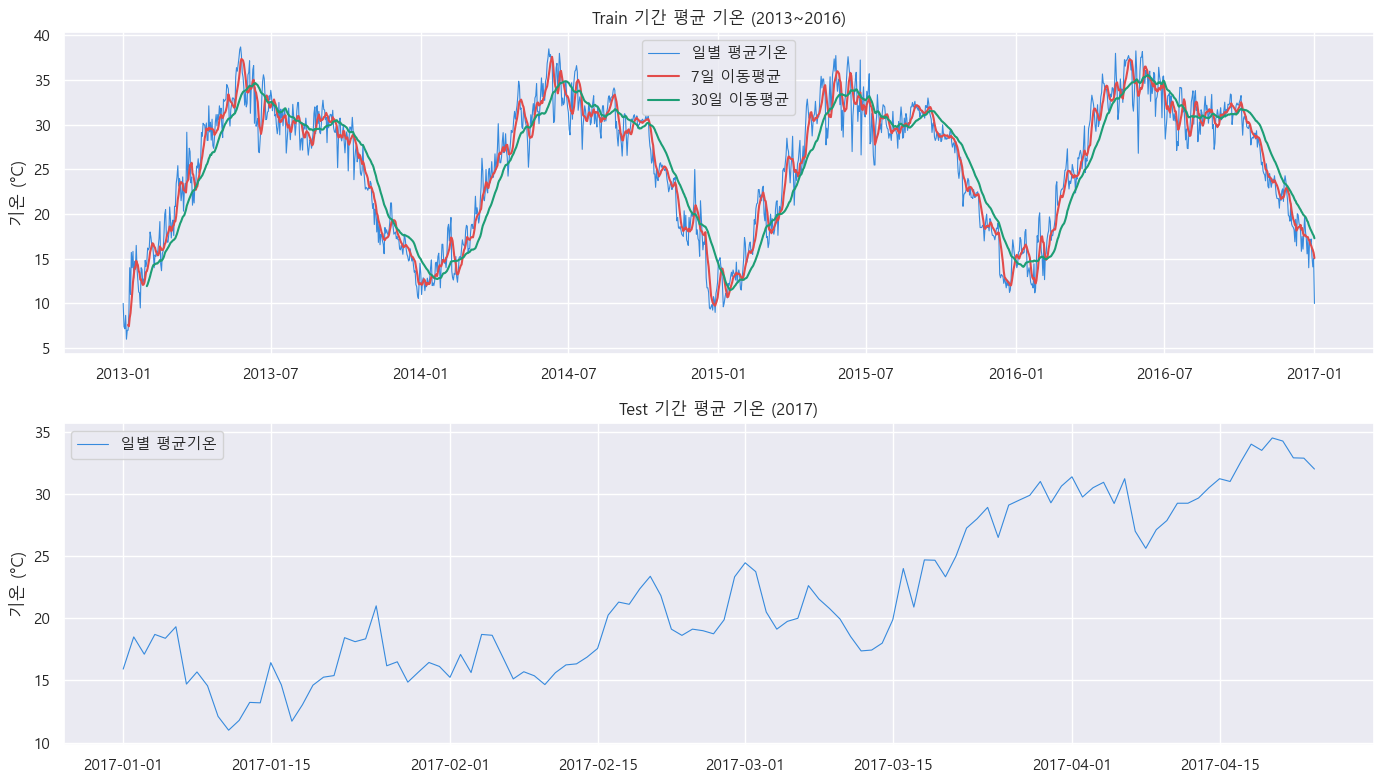

In [17]:
# ============================================================
# 3-1. 전체 기간 기온 시계열 시각화
# ============================================================
# 원본 기온 위에 이동평균을 겹쳐 단기 노이즈와 중기 추세를 동시에 파악
# Train·Test 기간의 계절 패턴이 유사한지 육안으로 확인

print("=" * 60)
print("3-1. 전체 기간 meantemp 시계열")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))                        # 2행 1열 서브플롯 생성 (Train / Test 각각)

# Train
axes[0].plot(df_train['date'], df_train['meantemp'],
             color='#378ADD', linewidth=0.8, label='일별 평균기온')   # 얇은 선으로 일별 변동 표현
axes[0].plot(df_train['date'], df_train['MA_7'],
             color='#E24B4A', linewidth=1.5, label='7일 이동평균')    # 단기 추세선
axes[0].plot(df_train['date'], df_train['MA_30'],
             color='#1D9E75', linewidth=1.5, label='30일 이동평균')   # 중기 추세선
axes[0].set_title('Train 기간 평균 기온 (2013~2016)', fontsize=12)
axes[0].set_ylabel('기온 (°C)')
axes[0].legend()                                                       # 범례 표시

# Test
axes[1].plot(df_test['date'], df_test['meantemp'],
             color='#378ADD', linewidth=0.8, label='일별 평균기온')   # Test는 기간 짧아 이동평균 생략
axes[1].set_title('Test 기간 평균 기온 (2017)', fontsize=12)
axes[1].set_ylabel('기온 (°C)')
axes[1].legend()

plt.tight_layout()                                                     # 서브플롯 간 여백 자동 조정
plt.show()

## <b>3-2. 4개 변수 전체 시각화

3-2. 4개 기후 변수 시계열


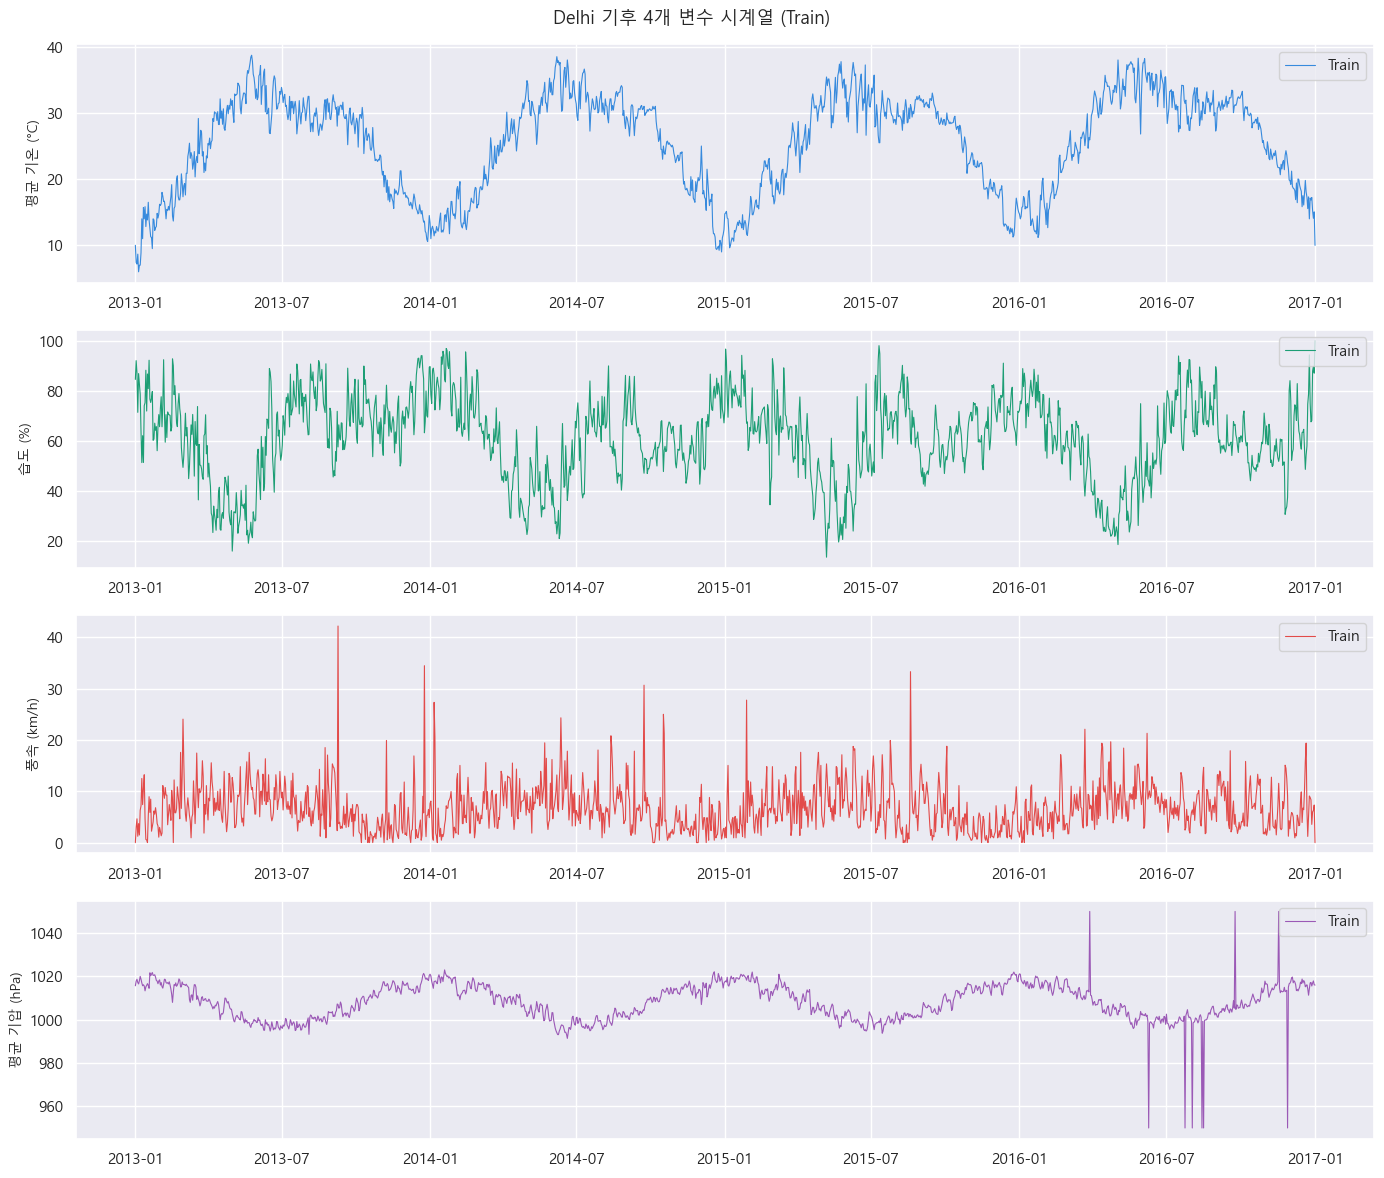

In [18]:
# ============================================================
# 3-2. 4개 변수 전체 시각화
# ============================================================
# 기온 외 습도·풍속·기압의 시계열 흐름을 한 화면에서 비교
# 변수 간 계절 패턴 동조 여부와 이상 구간을 동시에 포착

print("=" * 60)
print("3-2. 4개 기후 변수 시계열")
print("=" * 60)

vars_info = [
    ('meantemp',     '평균 기온 (°C)',  '#378ADD'),
    ('humidity',     '습도 (%)',        '#1D9E75'),
    ('wind_speed',   '풍속 (km/h)',     '#E24B4A'),
    ('meanpressure', '평균 기압 (hPa)', '#9B59B6'),
]                                                          # (컬럼명, y축 레이블, 색상) 튜플 목록

fig, axes = plt.subplots(4, 1, figsize=(14, 12))           # 4행 1열 서브플롯 (변수별 1개씩)

for ax, (col, label, color) in zip(axes, vars_info):       # 서브플롯과 변수 정보를 동시에 순회
    ax.plot(df_train['date'], df_train[col],
            color=color, linewidth=0.8, label='Train')     # 각 변수를 지정 색상으로 시계열 플롯
    ax.set_ylabel(label, fontsize=10)                      # y축 레이블에 단위 포함
    ax.legend(loc='upper right')                           # 범례를 우측 상단에 고정

plt.suptitle('Delhi 기후 4개 변수 시계열 (Train)', fontsize=13)   # 전체 그림 제목 (개별 타이틀 대신)
plt.tight_layout()                                               # suptitle과 서브플롯 간 겹침 방지
plt.show() 

## <b>3-3. 월별 기온 분포 (BoxPlot)

3-3. 월별 기온 분포


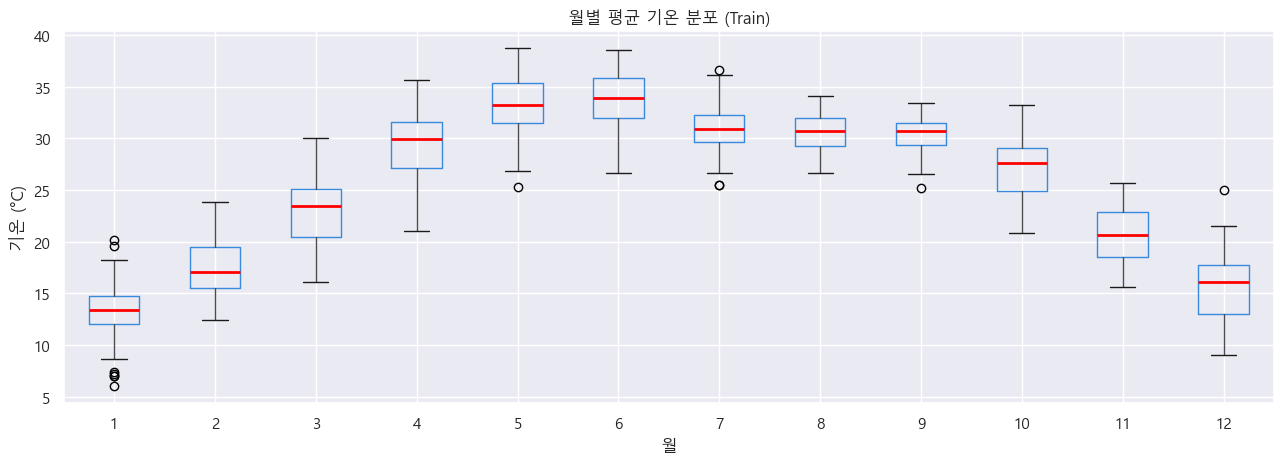


[월별 기온 통계]
          평균     최고     최저  표준편차
Month                           
1      13.31  20.14   6.00  2.47
2      17.62  23.88  12.38  2.92
3      22.91  30.00  16.12  3.26
4      29.38  35.69  21.00  3.01
5      33.32  38.71  25.25  2.79
6      33.73  38.50  26.62  2.70
7      31.00  36.62  25.50  2.19
8      30.60  34.12  26.60  1.78
9      30.43  33.44  25.20  1.51
10     27.11  33.27  20.88  2.64
11     20.66  25.64  15.57  2.43
12     15.67  25.00   9.00  3.13


In [19]:
# ============================================================
# 3-3. 월별 기온 분포 (BoxPlot)
# ============================================================
# 히스토그램으론 월별 비교가 어려움
# 박스플롯으로 중앙값·사분위·이상치를 월별로 한눈에 비교

print("=" * 60)
print("3-3. 월별 기온 분포")
print("=" * 60)

fig, ax = plt.subplots(figsize=(13, 5))
df_train.boxplot(column='meantemp', by='Month', ax=ax,        # Month 기준으로 meantemp를 그룹화해 박스플롯
                 boxprops=dict(color='#378ADD'),            # 박스 테두리 색상
                 medianprops=dict(color='red', linewidth=2))  # 중앙값 선 색상·굵기 강조
ax.set_title('월별 평균 기온 분포 (Train)', fontsize=12)
ax.set_xlabel('월')
ax.set_ylabel('기온 (°C)')
plt.suptitle('')                                           # pandas boxplot 자동 생성 제목 제거
plt.tight_layout()
plt.show()

monthly_stat = df_train.groupby('Month')['meantemp'].agg(  # Month 기준으로 그룹화
    평균='mean', 최고='max', 최저='min', 표준편차='std'      # 집계 함수를 한 번에 적용
).round(2)                                                 # 소수점 2자리로 반올림
print("\n[월별 기온 통계]")
print(monthly_stat)                                        # 월별 기온 통계 테이블 출력

## <b>3-4. 계절별 기온 분포

3-4. 계절별 기온 분포


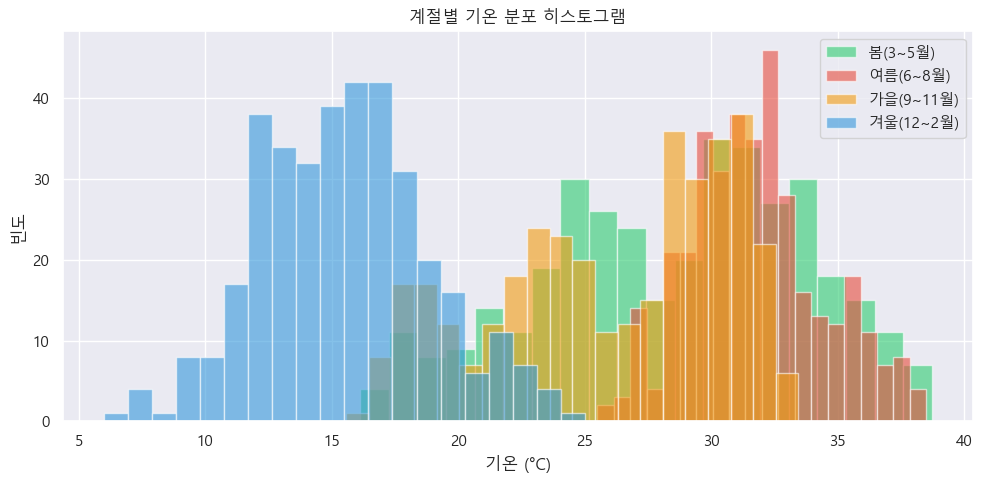


[계절별 기온 통계]
             count   mean   std    min    25%    50%    75%    max
Season_Name                                                       
봄(3~5월)      368.0  28.53  5.27  16.12  24.75  29.32  32.63  38.71
여름(6~8월)     368.0  31.76  2.64  25.50  29.88  31.55  33.25  38.50
가을(9~11월)    364.0  26.08  4.63  15.57  22.64  27.33  30.26  33.44
겨울(12~2월)    362.0  15.46  3.34   6.00  13.00  15.40  17.50  25.00


In [20]:
# ============================================================
# 3-4. 계절별 기온 분포
# ============================================================
# 월별보다 큰 단위인 계절로 묶어 기온 분포의 계절 간 차이를 파악
# 히스토그램 겹침(alpha)으로 계절 간 기온 범위 중복 여부 확인

print("=" * 60)
print("3-4. 계절별 기온 분포")
print("=" * 60)

season_map = {1: '봄(3~5월)', 2: '여름(6~8월)', 3: '가을(9~11월)', 4: '겨울(12~2월)'}
df_train['Season_Name'] = df_train['Season'].map(season_map)         # 계절 번호를 한글 이름으로 변환해 새 컬럼 생성

fig, ax = plt.subplots(figsize=(10, 5))
order  = ['봄(3~5월)', '여름(6~8월)', '가을(9~11월)', '겨울(12~2월)']  # 계절 표시 순서 고정
colors = ['#2ECC71', '#E74C3C', '#F39C12', '#3498DB']       # 계절별 색상 (봄·여름·가을·겨울)

for i, (season, color) in enumerate(zip(order, colors)):             # 계절·색상 쌍을 순서대로 순회
    data = df_train[df_train['Season_Name'] == season]['meantemp']   # 해당 계절 행만 필터링
    ax.hist(data, bins=20, alpha=0.6, color=color, label=season)     # alpha=0.6으로 겹친 부분 투명하게 표현

ax.set_xlabel('기온 (°C)')
ax.set_ylabel('빈도')
ax.set_title('계절별 기온 분포 히스토그램')
ax.legend()
plt.tight_layout()
plt.show()

print("\n[계절별 기온 통계]")
print(df_train.groupby('Season_Name')['meantemp']
      .describe()                                                    # count·mean·std·min·사분위·max 집계
      .round(2)
      .loc[order])                                                   # order 순서대로 행 정렬해 출력

## <b>3-5. 연도별 기온 추세

3-5. 연도별 기온 추세


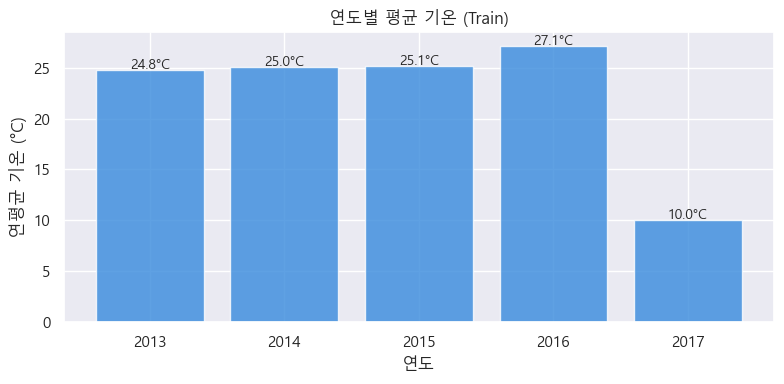


연도별 평균 기온:
Year
2013    24.79
2014    25.01
2015    25.11
2016    27.10
2017    10.00
Name: meantemp, dtype: float64


In [21]:
# ============================================================
# 3-5. 연도별 기온 추세
# ============================================================
# 월별·계절별 패턴 외에 연도 단위로 기온이 오르내리는지 확인
# 연간 기온 차이가 크면 연도 변수를 피처로 추가할 근거가 됨

print("=" * 60)
print("3-5. 연도별 기온 추세")
print("=" * 60)

yearly_avg = df_train.groupby('Year')['meantemp'].mean()         # 연도별 평균 기온 집계

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yearly_avg.index, yearly_avg.values,
       color='#378ADD', alpha=0.8)                             # 연도별 막대 그래프
ax.set_xlabel('연도')
ax.set_ylabel('연평균 기온 (°C)')
ax.set_title('연도별 평균 기온 (Train)')

for x, y in zip(yearly_avg.index, yearly_avg.values):            # 각 막대 위에 수치 레이블 추가
    ax.text(x, y + 0.1, f'{y:.1f}°C', ha='center', fontsize=10)  # y+0.1로 막대 바로 위에 띄움

plt.tight_layout()
plt.show()

print("\n연도별 평균 기온:")
print(yearly_avg.round(2))                                       # 수치로도 확인

## <b>3-6. 상관관계 분석

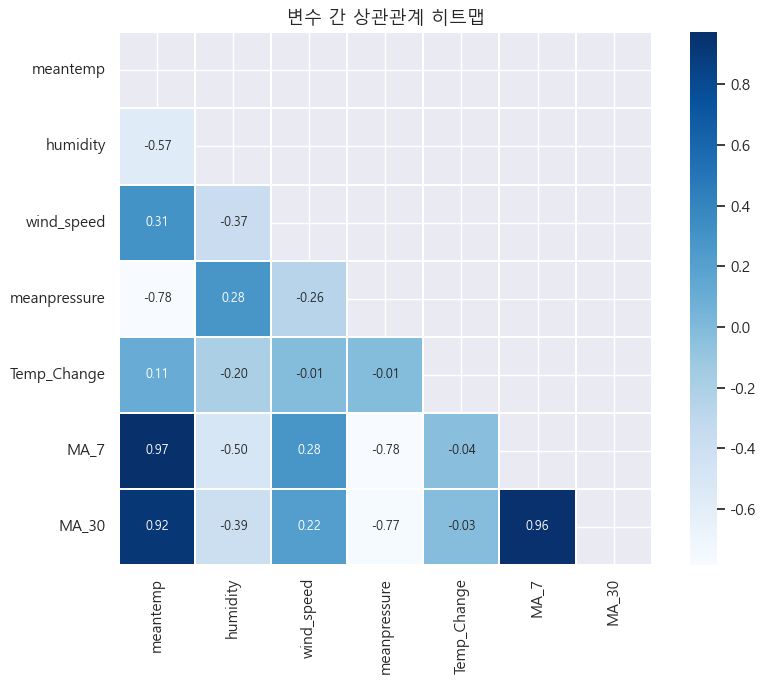


[상관계수 0.7 이상 항목]
  meantemp ↔ meanpressure: -0.781
  meantemp ↔ MA_7: 0.971
  meantemp ↔ MA_30: 0.919
  meanpressure ↔ MA_7: -0.784
  meanpressure ↔ MA_30: -0.766
  MA_7 ↔ MA_30: 0.958


In [22]:
# ============================================================
# 3-6. 상관관계 분석
#    - 4개 기후 변수 + 파생변수 간 선형 관계 확인
# ============================================================
# 높은 상관관계(0.7↑)는 다중공선성 문제를 일으킬 수 있어
# 모델 피처 선택 전에 반드시 확인

corr_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure',
             'Temp_Change', 'MA_7', 'MA_30']
corr = df_train[corr_cols].corr().round(3)                     # 지정 컬럼 간 피어슨 상관계수 행렬 계산

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))                 # 상삼각 행렬 마스크 (대각선 포함) → 중복 제거
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, linewidths=0.3, square=True,
            annot_kws={'size': 9}, ax=ax)                      # 하삼각만 표시, 셀 안에 수치 표기
ax.set_title('변수 간 상관관계 히트맵', fontsize=13)
plt.tight_layout()
plt.show()

print("\n[상관계수 0.7 이상 항목]")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):                    # 하삼각만 순회 (중복 출력 방지)
        val = corr.iloc[i, j]
        if abs(val) >= 0.7:                                    # 절댓값 기준 → 강한 음의 상관도 포착
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {val}")
            found = True
if not found:
    print("  해당 없음")                                       # 다중공선성 우려 없음

## <b>3-7. 정상성 검정 (ADF Test)

In [23]:
# ============================================================
# 3-7. 정상성 검정 — ADF Test (Augmented Dickey-Fuller)
#    - 시계열 모델링 전 필수 확인
#    - p-value < 0.05 → 정상성 O
#    - 날씨 데이터: 강한 계절성(seasonality) 존재 가능
# ============================================================
# 비정상 시계열(평균·분산이 시간에 따라 변함)은 ARIMA 등 모델에 바로 쓸 수 없음
# 원본과 차분값(Temp_Change)을 함께 검정해 차분 효과를 비교

print("\n" + "=" * 50)
print("ADF 정상성 검정")
print("=" * 50)

targets = {
    'meantemp (원본)' : df_train['meantemp'].dropna(),       # 원본 기온 → 계절성으로 비정상일 가능성 높음
    'Temp_Change'     : df_train['Temp_Change'].dropna(),    # 1차 차분값 → 정상성 확보 여부 확인
    'humidity'        : df_train['humidity'].dropna(),
    'meanpressure'    : df_train['meanpressure'].dropna(),
}

for name, series in targets.items():                         # 각 시계열에 대해 ADF 검정 실행
    result = adfuller(series)
    stat, pval = result[0], result[1]                        # ADF 통계량·p-value 추출
    stationary = "정상 ✓" if pval < 0.05 else "비정상 ⚠"     # p-value 0.05 기준으로 정상성 판정
    print(f"\n  [{name}]")
    print(f"    ADF 통계량 : {stat:.4f}")                     # 값이 더 음수일수록 정상성 강함
    print(f"    p-value    : {pval:.4f}")                    # 0.05 미만이면 귀무가설(단위근 존재) 기각
    print(f"    결론       : {stationary}")


ADF 정상성 검정

  [meantemp (원본)]
    ADF 통계량 : -2.0211
    p-value    : 0.2774
    결론       : 비정상 ⚠

  [Temp_Change]
    ADF 통계량 : -16.3787
    p-value    : 0.0000
    결론       : 정상 ✓

  [humidity]
    ADF 통계량 : -3.6756
    p-value    : 0.0045
    결론       : 정상 ✓

  [meanpressure]
    ADF 통계량 : -2.1527
    p-value    : 0.2239
    결론       : 비정상 ⚠


## <b>3-8. ACF / PACF

3-8. ACF / PACF


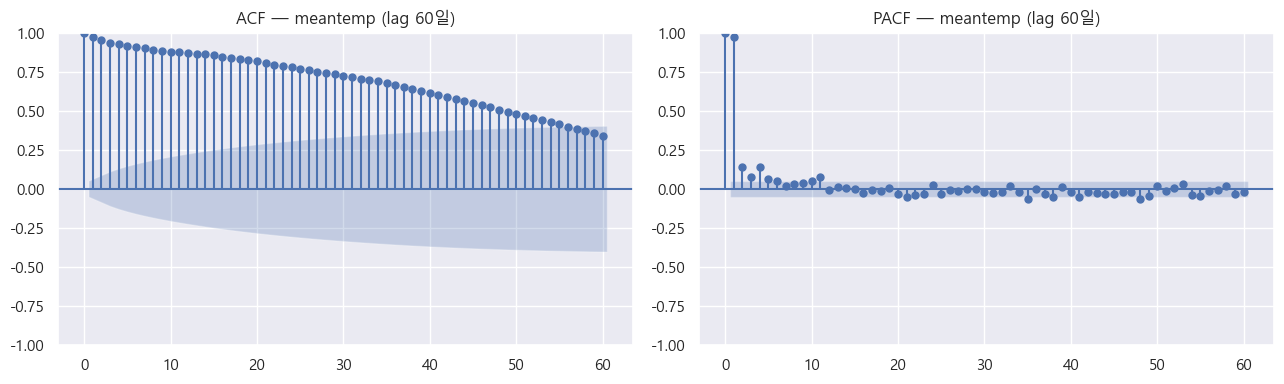


→ ACF가 완만히 감소 (비정상 또는 강한 계절성)
→ LSTM window=30 적용 → 4-3에서 반영


In [24]:
# ============================================================
# 3-8. ACF / PACF 분석
#    - 자기상관 구조 파악 → LSTM window size 결정 참고
#    - 날씨 데이터: 계절성(~365일 lag) + 단기 자기상관 공존
# ============================================================
# ACF: 몇 lag 전 값까지 현재에 영향을 주는지 확인
# PACF: 중간 lag의 영향을 제거한 순수 자기상관 → AR 차수 결정에 활용

print("=" * 60)
print("3-8. ACF / PACF")
print("=" * 60)

series_acf = df_train['meantemp'].dropna()                    # 결측치 제거 후 기온 시계열 준비

fig, axes = plt.subplots(1, 2, figsize=(13, 4))               # ACF·PACF 나란히 배치
plot_acf(series_acf,  lags=60, ax=axes[0],
         title='ACF — meantemp (lag 60일)')                   # lag 60일까지 자기상관계수 시각화
plot_pacf(series_acf, lags=60, ax=axes[1],
          title='PACF — meantemp (lag 60일)')                 # lag 60일까지 편자기상관계수 시각화
                                                              # 음영 범위 밖이면 통계적으로 유의미한 lag
plt.tight_layout()
plt.show()

print("\n→ ACF가 완만히 감소 (비정상 또는 강한 계절성)")         # ACF 결과 해석 요약
print("→ LSTM window=30 적용 → 4-3에서 반영")                  # ACF 분석 결과를 실제 모델에 반영

# <b>4. 피처 엔지니어링 및 데이터셋 준비

## <b>4-1. 모델용 데이터프레임 구성

In [25]:
# ============================================================
# 4-1. 모델용 데이터프레임 구성
#
#    - Train / Test 분리는 이미 CSV 파일로 제공됨
#    - Train 내부에서 Val 분리 (시간순 — 80/10/10)
#    - 피처: meantemp, humidity, wind_speed, meanpressure,
#             MA_7, MA_30, Season,
#             Month, DayOfYear,
#             month_sin, month_cos, day_sin, day_cos (계절 주기)
#    - 타겟: meantemp (다음날 기온)
# ============================================================
# 모델에 실제로 투입할 피처와 타겟을 명시적으로 고정
# rolling 계산으로 생긴 앞부분 NaN을 제거하지 않으면 학습 오류 발생

print("=" * 60)
print("4-1. 모델용 데이터프레임 구성")
print("=" * 60)

FEATURE_COLS = ['meantemp', 'humidity', 'wind_speed', 'meanpressure',
                'MA_7', 'MA_30',                                           # 단기·중기 추세 피처 추가 (ACF 분석 반영)
                'Season',                                                  # 계절 번호 피처 추가
                'Month', 'DayOfYear',
                'month_sin', 'month_cos', 'day_sin', 'day_cos']            # 모델 입력 피처 목록 (상수로 고정)
TARGET_COL   = 'meantemp'                                                  # 예측 대상 컬럼

df_model_tr = df_train.dropna(subset=FEATURE_COLS).reset_index(drop=True)  # MA_30 계산으로 생긴 앞 30행 NaN 제거
df_model_te = df_test.copy()                                               # 원본 보존을 위해 복사본 사용

df_model_te[FEATURE_COLS] = df_model_te[FEATURE_COLS].bfill().ffill()      # Test 앞부분 NaN을 뒷값→앞값 순으로 채움
                                                                           # Test는 기간이 짧아 rolling NaN 비율이 높을 수 있음
print(f"Train (NaN 제거 후): {df_model_tr.shape}")                          # (행 수, 컬럼 수) 확인
print(f"Test               : {df_model_te.shape}")
print(f"피처 컬럼 ({len(FEATURE_COLS)}개): {FEATURE_COLS}")                 # 피처 수·목록 확인
print(f"타겟 컬럼: {TARGET_COL}")

4-1. 모델용 데이터프레임 구성
Train (NaN 제거 후): (1433, 17)
Test               : (114, 16)
피처 컬럼 (13개): ['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'MA_7', 'MA_30', 'Season', 'Month', 'DayOfYear', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
타겟 컬럼: meantemp


## <b>4-2. 스케일링

In [26]:
# ============================================================
# 4-2. MinMaxScaler 적용
#    - scaler: Train 데이터로만 fit → Data Leakage 방지
#    - 피처 스케일러 (X용) + 타겟 스케일러 (y용) 분리
# ============================================================
# LSTM은 입력값 크기에 민감하므로 0~1 범위로 정규화 필수
# Test 정보가 scaler에 섞이면 미래 데이터를 미리 본 셈 → 반드시 Train만 fit

print("=" * 60)
print("4-2. MinMaxScaler 적용")
print("=" * 60)

scaler_X = MinMaxScaler(feature_range=(0, 1))                  # 피처용 스케일러 (0~1 범위)
scaler_y = MinMaxScaler(feature_range=(0, 1))                  # 타겟용 스케일러 분리
                                                               # → 예측값을 원래 기온으로 역변환할 때 필요

X_train_raw = df_model_tr[FEATURE_COLS].values                 # 피처 numpy 배열 추출
y_train_raw = df_model_tr[[TARGET_COL]].values                 # 타겟 2D 배열로 추출 (scaler 입력 형식)

X_test_raw  = df_model_te[FEATURE_COLS].values
y_test_raw  = df_model_te[[TARGET_COL]].values

scaler_X.fit(X_train_raw)                                      # Train 데이터로만 fit (min·max 기준 학습)
scaler_y.fit(y_train_raw)                                      # 타겟도 Train으로만 fit

X_train_scaled = scaler_X.transform(X_train_raw)               # fit된 기준으로 Train 변환
y_train_scaled = scaler_y.transform(y_train_raw).flatten()     # 1D로 펼침 (모델 학습 입력 형식)

X_test_scaled  = scaler_X.transform(X_test_raw)                # Train 기준으로 Test 변환 (fit 없음)
y_test_scaled  = scaler_y.transform(y_test_raw).flatten()

print(f"X_train_scaled: {X_train_scaled.shape}")               # (행 수, 피처 수) 확인
print(f"X_test_scaled : {X_test_scaled.shape}")
print("스케일링 완료 (Train fit → Test transform)")

4-2. MinMaxScaler 적용
X_train_scaled: (1433, 13)
X_test_scaled : (114, 13)
스케일링 완료 (Train fit → Test transform)


## <b>4-3. 시퀀스 데이터 생성

In [27]:
# ============================================================
# 4-3. 시퀀스 데이터 생성 (Sliding Window)
#
#    - WINDOW_SIZE = 30 (30일 기온 패턴으로 다음날 예측)
#    - X[i-30:i] → y[i] : X 마지막날 기준 바로 다음날 예측
#    - X: (샘플수, 30, 피처수)  y: (샘플수,)
# ============================================================
# LSTM은 고정 길이 시퀀스를 입력받으므로
# 슬라이딩 윈도우로 (과거 30일 → 다음날) 쌍을 반복 생성

print("=" * 60)
print("4-3. 시퀀스 데이터 생성")
print("=" * 60)

WINDOW_SIZE = 30                                               # ACF 분석 결과 반영

def create_sequences(X_scaled, y_scaled, window_size):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X_scaled)):                # 윈도우 크기만큼 앞을 건너뛰며 시작
        X_seq.append(X_scaled[i - window_size:i, :])           # 과거 window_size일치 피처 슬라이싱
        y_seq.append(y_scaled[i])                              # 바로 다음날 기온을 타겟으로
    return np.array(X_seq), np.array(y_seq)

X_all, y_all = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)  # Train 전체로 시퀀스 생성

# Train / Val 분리 (시간순: 80 / 20)
n = len(X_all)
train_end = int(n * 0.80)                                      # 시간순 분리 → 미래 데이터가 Val에 위치

X_train = X_all[:train_end];  y_train = y_all[:train_end]      # 앞 80% → 학습용
X_val   = X_all[train_end:];  y_val   = y_all[train_end:]      # 뒤 20% → 검증용

# Test 시퀀스
# Test 앞에 Train 끝부분을 붙여서 윈도우 확보
X_combined = np.vstack([X_train_scaled[-WINDOW_SIZE:], X_test_scaled])       # Test 첫 행도 30일 윈도우를 갖도록
y_combined = np.concatenate([y_train_scaled[-WINDOW_SIZE:], y_test_scaled])  # Train 마지막 30일을 앞에 이어붙임
X_test, y_test = create_sequences(X_combined, y_combined, WINDOW_SIZE)

print(f"WINDOW_SIZE : {WINDOW_SIZE}일 (ACF 분석 기반)")
print(f"X_train     : {X_train.shape}  y_train: {y_train.shape}")            # (샘플수, 30, 피처수) 확인
print(f"X_val       : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test      : {X_test.shape}   y_test : {y_test.shape}")

4-3. 시퀀스 데이터 생성
WINDOW_SIZE : 30일 (ACF 분석 기반)
X_train     : (1122, 30, 13)  y_train: (1122,)
X_val       : (281, 30, 13)    y_val  : (281,)
X_test      : (114, 30, 13)   y_test : (114,)


# <b>5. LSTM 모델 구성 및 학습

## <b>5-1. 모델 아키텍처 구성

In [28]:
# ============================================================
# 5-1. 모델 아키텍처 구성
#    - LSTM 2층 구조 (다변량 입력 → 기온 1개 예측)
#    - 1층: return_sequences=True → 다음 LSTM에 시퀀스 전달
#    - 2층: return_sequences=False
#    - Dropout 0.2: 과적합 방지
# ============================================================
# 1층 LSTM이 시간 패턴을 추출하고 2층 LSTM이 이를 압축
# Dropout으로 특정 뉴런 의존도를 낮춰 일반화 성능 향상

print("=" * 60)
print("5-1. 모델 아키텍처 구성")
print("=" * 60)

INPUT_SHAPE  = (X_train.shape[1], X_train.shape[2])            # (WINDOW_SIZE, 피처 수) → LSTM 입력 형태
LSTM_UNITS_1 = 64                                              # 1층 LSTM 셀 수 (많을수록 표현력↑, 과적합 위험↑)
LSTM_UNITS_2 = 32                                              # 2층은 절반으로 줄여 점진적 압축
DROPOUT_RATE = 0.2                                             # 학습 시 20% 뉴런을 무작위로 비활성화

model = Sequential([
    LSTM(LSTM_UNITS_1,
         input_shape=INPUT_SHAPE,
         return_sequences=True,                                # True → 각 타임스텝 출력을 다음 층에 전달
         kernel_initializer=GlorotNormal(seed=42)),            # 가중치 초기화 (기울기 소실 완화)
    Dropout(DROPOUT_RATE),                                     # 1층 LSTM 후 Dropout

    LSTM(LSTM_UNITS_2,
         return_sequences=False,                               # False → 마지막 타임스텝 출력만 전달
         kernel_initializer=GlorotNormal(seed=42)),
    Dropout(DROPOUT_RATE),                                     # 2층 LSTM 후 Dropout

    Dense(1)                                                   # 최종 출력층 → 스칼라 1개 (다음날 기온)
])

model.summary()                                                # 층별 파라미터 수·출력 형태 출력
print()

5-1. 모델 아키텍처 구성


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

## <b>5-2. 모델 컴파일

In [29]:
# ============================================================
# 5-2. 모델 컴파일
#    - optimizer: Adam
#    - loss: MSE (기온 예측 회귀)
#    - metrics: MAE (직관적 오차 모니터링)
# ============================================================
# MSE는 큰 오차에 더 큰 패널티를 줘 이상치에 민감하게 학습
# MAE는 실제 오차 크기(°C 단위)를 직관적으로 모니터링하기 위해 추가

print("=" * 60)
print("5-2. 모델 컴파일")
print("=" * 60)

model.compile(
    optimizer='adam',                                         # 학습률 자동 조정 → 대부분의 경우 기본 선택
    loss='mse',                                               # 손실함수: 예측값과 실제값 차이의 제곱 평균
    metrics=['mae']                                           # 모니터링용: 평균 절대 오차 (손실과 별도 추적)
)

print("optimizer : Adam")
print("loss      : MSE (Mean Squared Error)")
print("metrics   : MAE (Mean Absolute Error)\n")

5-2. 모델 컴파일
optimizer : Adam
loss      : MSE (Mean Squared Error)
metrics   : MAE (Mean Absolute Error)



## <b>5-3. 콜백 설정

In [30]:
# ============================================================
# 5-3. 콜백 설정
#    - EarlyStopping: val_loss 기준, patience=15
#    - ModelCheckpoint: 최고 성능 모델 저장
# ============================================================
# 정해진 epoch을 끝까지 돌리면 과적합 구간까지 학습할 수 있음
# val_loss가 개선되지 않으면 자동으로 중단해 최적 시점의 모델을 보존

print("=" * 60)
print("5-3. 콜백 설정")
print("=" * 60)

MODEL_PATH = 'best_delhi_lstm.keras'                           # 저장할 모델 파일 경로

early_stopping = EarlyStopping(
    monitor='val_loss',                                        # 검증 손실 기준으로 개선 여부 판단
    patience=15,                                               # 15 epoch 연속 개선 없으면 학습 중단
    restore_best_weights=True,                                 # 중단 시 val_loss 최소였던 가중치로 복원
    verbose=1                                                  # 중단 시점 epoch 번호 출력
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor='val_loss',                                        # val_loss 기준으로 최고 모델 선별
    save_best_only=True,                                       # 갱신될 때만 저장 (불필요한 덮어쓰기 방지)
    verbose=1                                                  # 저장 시점마다 로그 출력
)

print(f"EarlyStopping   : val_loss 기준, patience=15")
print(f"ModelCheckpoint : '{MODEL_PATH}' 저장\n")

5-3. 콜백 설정
EarlyStopping   : val_loss 기준, patience=15
ModelCheckpoint : 'best_delhi_lstm.keras' 저장



## <b>5-4. 모델 학습

In [31]:
# ============================================================
# 5-4. 모델 학습
# ============================================================
# 시계열은 순서가 중요하므로 shuffle=False 필수
# EarlyStopping이 과적합 시점을 자동으로 감지해 조기 종료

print("=" * 60)
print("5-4. 모델 학습")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    epochs=100,                                                # 최대 학습 횟수 (EarlyStopping으로 조기 종료 가능)
    batch_size=32,                                             # 한 번에 32개 샘플씩 가중치 업데이트
    validation_data=(X_val, y_val),                            # 매 epoch마다 val_loss 계산 (학습에는 미사용)
    callbacks=[early_stopping, checkpoint],                    # 조기 종료 + 최고 모델 저장 콜백 등록
    shuffle=False,                                             # 시계열 순서 보존 → True면 시간 관계 파괴
    verbose=1                                                  # epoch별 loss·mae·val_loss·val_mae 출력
)

print(f"\n학습 완료 — 총 에폭: {len(history.history['loss'])}회")        # 실제로 학습된 epoch 수
print(f"최종 Val Loss: {min(history.history['val_loss']):.6f}")         # 전체 epoch 중 최소 val_loss

5-4. 모델 학습
Epoch 1/100
32/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1482 - mae: 0.3192
Epoch 1: val_loss improved from None to 0.01057, saving model to best_delhi_lstm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1309 - mae: 0.2813 - val_loss: 0.0106 - val_mae: 0.0799
Epoch 2/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0221 - mae: 0.1187
Epoch 2: val_loss improved from 0.01057 to 0.00753, saving model to best_delhi_lstm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0202 - mae: 0.1121 - val_loss: 0.0075 - val_mae: 0.0708
Epoch 3/100
33/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148 - mae: 0.0986
Epoch 3: val_loss improved from 0.00753 to 0.00661, saving model to best_delhi_lstm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0146 - mae: 0.0970 - val_loss: 0.0066 - val_mae: 0.0657
Epoch 4/100
31/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0150 - mae: 0.0949
Epoch 4: val_loss improved from 0.00661 to 0.00587, saving model to best_delhi_lstm

## <b>5-5. 학습 곡선 시각화

5-5. 학습 곡선 (Loss / MAE)


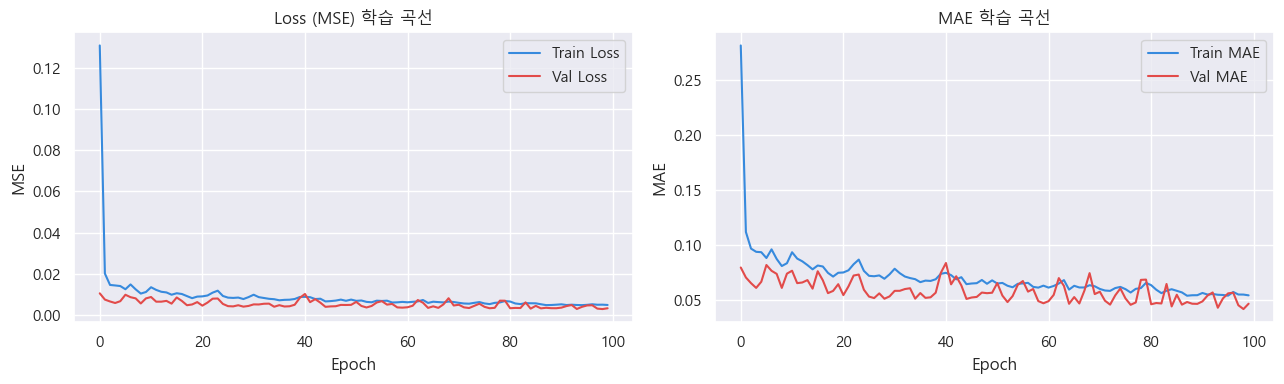

In [32]:
# ============================================================
# 5-5. 학습 곡선 시각화
# ============================================================
# Train·Val 곡선 간격으로 과적합 여부를 시각적으로 진단
# Val Loss가 Train Loss보다 크게 벌어지면 과적합 신호

print("=" * 60)
print("5-5. 학습 곡선 (Loss / MAE)")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))                  # Loss·MAE 곡선을 나란히 배치

axes[0].plot(history.history['loss'],
             label='Train Loss', color='#378ADD')              # epoch별 Train MSE 추이
axes[0].plot(history.history['val_loss'],
             label='Val Loss',   color='#E24B4A')              # epoch별 Val MSE 추이
axes[0].set_title('Loss (MSE) 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'],
             label='Train MAE', color='#378ADD')               # epoch별 Train MAE 추이 (°C 단위 직관적 확인)
axes[1].plot(history.history['val_mae'],
             label='Val MAE',   color='#E24B4A')               # epoch별 Val MAE 추이
axes[1].set_title('MAE 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# <b>6. 모델 평가

<pre>
** <font color="red">평가 매트릭스</font> **
(R)MSE : 단순 수치 차이
(R)MSLogE : 비율(증강률)이 중요

증감율에 대한 오차를 계산하고 싶은 경우
작은 수치의 오차에 민감하게 반응해야 하는 경우
성장률/비율이 중요한 경우 - 매출/재고 증강률, 환율, 금리(이자율)
음수값 계산 불가

 y    pred      mse        
100    110      10    ---   10%
1000  1010      10    ---    1%


| 지표 | 수식 (Formula) | 특징 및 용도 | 비고 |
| :--- | :---: | :--- | :--- |
| **MSE** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | 오차를 제곱하여 계산. 큰 오차에 매우 민감함. | 학습용 **Loss**로 주로 사용 |
| **RMSE** | $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ | MSE에 루트를 씌움. 실제 데이터와 단위가 일치함. | 일반적인 성능 **Metric** |
| **RMSLE** | $\sqrt{\frac{1}{n} \sum (\log(y_i+1) - \log(\hat{y}_i+1))^2}$ | 로그를 씌워 계산. 상대적 비율 오차를 측정함. | 아웃라이어가 많을 때 유리 |
| **MAE** | $\frac{1}{n} \sum \|y_i - \hat{y}_i\|$ | 오차의 절댓값 평균. 이상치 영향이 적음. | 직관적인 **평균 오차 크기** |
| **MAPE** | $\frac{100}{n} \sum \left\|\frac{y_i - \hat{y}_i}{y_i}\right\|$ | 오차를 퍼센트(%)로 표현. 단위에 무관함. | 값이 0에 가까울 때 불안정 |

## <b>6-1. Test 예측 및 역변환

In [33]:
# ============================================================
# 6-1. Test 예측 및 역변환
# ============================================================
# 모델 출력은 0~1로 스케일된 값이므로 실제 기온(°C)으로 되돌려야
# 실제 성능을 체감할 수 있는 수치로 평가 가능

print("=" * 60)
print("6-1. Test 예측 및 역변환")
print("=" * 60)

y_pred_scaled = model.predict(X_test, verbose=0).flatten()     # 스케일된 예측값 생성 후 1D로 변환

y_pred_actual = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)).flatten()                    # 예측값을 원래 기온(°C) 단위로 역변환
y_true_actual = scaler_y.inverse_transform(
    y_test.reshape(-1, 1)).flatten()                           # 실제값도 동일하게 역변환 (비교 기준)

print(f"예측 샘플 수: {len(y_pred_actual)}개")
print(f"실제 기온 범위: {y_true_actual.min():.1f}°C ~ {y_true_actual.max():.1f}°C")  # 실제 기온 분포
print(f"예측 기온 범위: {y_pred_actual.min():.1f}°C ~ {y_pred_actual.max():.1f}°C")  # 예측 기온 분포 (실제와 비교)

6-1. Test 예측 및 역변환
예측 샘플 수: 114개
실제 기온 범위: 11.0°C ~ 34.5°C
예측 기온 범위: 13.3°C ~ 33.5°C


## <b>6-2. 성능 지표 계산

In [34]:
# ============================================================
# 6-2. 성능 지표 계산
#    - RMSE : 큰 오차에 민감한 지표
#    - MAE  : 평균 절대 오차 (단위: °C)
#    - MAPE : 퍼센트 오차 (직관적 해석)
#    - RMSLE: 과소예측에 민감한 로그 스케일 오차
# ============================================================
# 지표 하나만으론 모델을 오판할 수 있어 네 가지를 함께 확인
# RMSE로 이상 예측을, MAE로 평균 오차를, MAPE로 상대적 정확도를,
# RMSLE로 과소예측 민감도를 파악

print("=" * 60)
print("6-2. 성능 지표")
print("=" * 60)

rmse_test  = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))    # 오차 제곱 평균의 제곱근 → 큰 오차에 가중
mae_test   = mean_absolute_error(y_true_actual, y_pred_actual)            # 오차 절댓값 평균 → °C 단위 직관적 해석
mape_test  = np.mean(np.abs(
    (y_true_actual - y_pred_actual) / (y_true_actual + 1e-8)
)) * 100                                                                  # 퍼센트 오차 평균, 1e-8로 0 나눔 방지
rmsle_test = np.sqrt(np.mean(
    (np.log1p(np.maximum(y_pred_actual, 0)) -
     np.log1p(np.maximum(y_true_actual, 0))) ** 2
))                                                                        # 음수 기온 대비 0으로 클리핑 후 log1p 적용

print(f"  RMSE  : {rmse_test:.4f} °C")                                  # 낮을수록 이상 예측이 적음
print(f"  MAE   : {mae_test:.4f} °C")                                   # 평균적으로 몇 °C 틀렸는지
print(f"  MAPE  : {mape_test:.2f} %")                                   # 실제값 대비 몇 % 틀렸는지
print(f"  RMSLE : {rmsle_test:.4f}")                                    # 낮을수록 과소예측이 적음

6-2. 성능 지표
  RMSE  : 1.9735 °C
  MAE   : 1.6619 °C
  MAPE  : 8.52 %
  RMSLE : 0.0980


## <b>6-3. 예측 vs 실제 시각화

6-3. Test 예측 vs 실제 기온 시각화


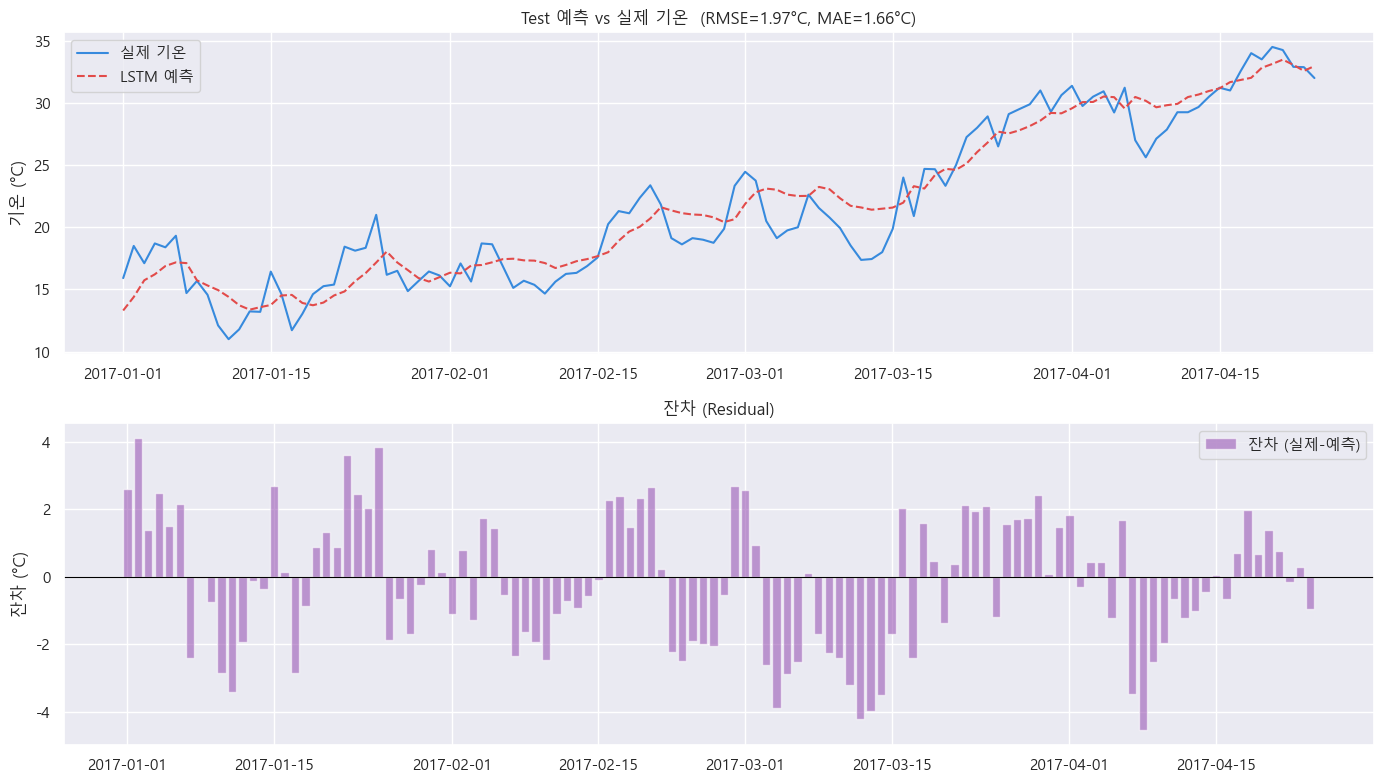

In [35]:
# ============================================================
# 6-3. 예측 vs 실제 시각화
# ============================================================
# 수치 지표만으론 어느 구간에서 틀렸는지 알 수 없음
# 시각화로 예측 패턴과 잔차 분포를 함께 확인

print("=" * 60)
print("6-3. Test 예측 vs 실제 기온 시각화")
print("=" * 60)

# y_test는 Train 끝 WINDOW_SIZE개를 앞에 붙여 시퀀스를 만들었으므로
# Test 날짜 전체(114개)가 그대로 대응됨 → WINDOW_SIZE 슬라이싱 불필요
n_pred = len(y_pred_actual)
test_dates_plot = pd.to_datetime(df_test['date'].values[:n_pred])      # 예측 샘플 수만큼 날짜 슬라이싱

fig, axes = plt.subplots(2, 1, figsize=(14, 8))                        # 예측비교·잔차 2행으로 배치

# 예측 vs 실제
axes[0].plot(test_dates_plot, y_true_actual[:n_pred],
             color='#378ADD', linewidth=1.5, label='실제 기온')       # 실제 기온 실선
axes[0].plot(test_dates_plot, y_pred_actual,
             color='#E24B4A', linewidth=1.5,
             linestyle='--', label='LSTM 예측')                         # 예측 기온 점선 (실제와 구분)
axes[0].set_title(f'Test 예측 vs 실제 기온  '
                  f'(RMSE={rmse_test:.2f}°C, MAE={mae_test:.2f}°C)',
                  fontsize=12)                                          # 제목에 핵심 지표 바로 표기
axes[0].set_ylabel('기온 (°C)')
axes[0].legend()

# 잔차
residuals = y_true_actual[:n_pred] - y_pred_actual                      # 잔차 = 실제 - 예측 (양수: 과소예측)
axes[1].bar(test_dates_plot, residuals,
            color='#9B59B6', alpha=0.6, label='잔차 (실제-예측)')      # 날짜별 잔차 막대 그래프
axes[1].axhline(0, color='black', linewidth=0.8)                        # 기준선 (잔차=0)
axes[1].set_title('잔차 (Residual)')
axes[1].set_ylabel('잔차 (°C)')
axes[1].legend()

plt.tight_layout()
plt.show()

## <b>6-4. 산점도 (실제 vs 예측)

6-4. 실제 vs 예측 산점도


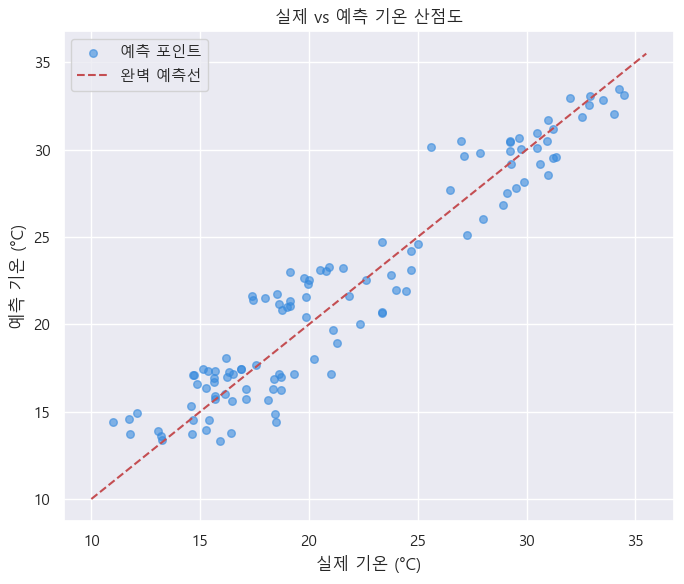

R² : 0.9029


In [36]:
# ============================================================
# 6-4. 산점도 (실제 vs 예측)
# ============================================================
# 수치 지표와 시계열 그래프만으론 예측 편향 방향을 파악하기 어려움
# 산점도로 완벽 예측선(y=x)에서 얼마나 벗어나는지 한눈에 확인

print("=" * 60)
print("6-4. 실제 vs 예측 산점도")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_actual[:n_pred], y_pred_actual,
           color='#378ADD', alpha=0.6, s=30, label='예측 포인트')      # 실제(x) vs 예측(y) 점 분포
min_v = min(y_true_actual.min(), y_pred_actual.min()) - 1
max_v = max(y_true_actual.max(), y_pred_actual.max()) + 1               # 축 범위를 데이터에 맞게 설정
ax.plot([min_v, max_v], [min_v, max_v],
        'r--', linewidth=1.5, label='완벽 예측선')                       # y=x 기준선 → 점이 가까울수록 정확
ax.set_xlabel('실제 기온 (°C)')
ax.set_ylabel('예측 기온 (°C)')
ax.set_title('실제 vs 예측 기온 산점도')
ax.legend()
plt.tight_layout()
plt.show()

ss_res = np.sum((y_true_actual[:n_pred] - y_pred_actual) ** 2)                  # 잔차 제곱합 (예측 오차)
ss_tot = np.sum((y_true_actual[:n_pred] - y_true_actual[:n_pred].mean()) ** 2)  # 전체 분산 (평균 기준 오차)
r2 = 1 - ss_res / ss_tot                                                        # R² = 1 - (잔차분산 / 전체분산)
print(f"R² : {r2:.4f}")                                                         # 1에 가까울수록 모델 설명력 높음

## <b>6-5. 전체 파이프라인 요약

In [37]:
# ============================================================
# 전체 파이프라인 요약
# ============================================================
# 분석 전 과정을 한 셀에서 조감
# 수치가 변수에서 직접 참조되므로 결과가 바뀌어도 자동 반영

print("=" * 60)
print("전체 파이프라인 요약")
print("=" * 60)
print(f"  1. 데이터 확인     : Train {len(df_train)}행, Test {len(df_test)}행")
print(f"  2. 전처리          : 결측치 보간, meanpressure 클리핑, 파생변수 생성")
print(f"  3. EDA             : 추세/계절성/상관관계/ADF/ACF 분석")
print(f"  4. 피처 엔지니어링 : window={WINDOW_SIZE}일(ACF 기반), 피처={len(FEATURE_COLS)}개")
print(f"  5. LSTM 학습       : 2층 LSTM, EarlyStopping")
print(f"  6. 평가            : RMSE={rmse_test:.2f}°C, MAE={mae_test:.2f}°C, "  # 6-2에서 계산한 지표 참조
      f"MAPE={mape_test:.2f}%, RMSLE={rmsle_test:.4f}, R²={r2:.4f}")            
print()

전체 파이프라인 요약
  1. 데이터 확인     : Train 1462행, Test 114행
  2. 전처리          : 결측치 보간, meanpressure 클리핑, 파생변수 생성
  3. EDA             : 추세/계절성/상관관계/ADF/ACF 분석
  4. 피처 엔지니어링 : window=30일(ACF 기반), 피처=13개
  5. LSTM 학습       : 2층 LSTM, EarlyStopping
  6. 평가            : RMSE=1.97°C, MAE=1.66°C, MAPE=8.52%, RMSLE=0.0980, R²=0.9029



# <b>7. 미래 예측

## <b>7-1. 다변량 롤링 예측 (계절 피처 포함)

In [38]:
# ============================================================
# 7. 미래 예측 (1년 — 365일)
#
#    [방식]
#    - 다변량 + 계절 피처 주입으로 수평 수렴 방지
#    - seed: X_test_scaled[-WINDOW_SIZE:] 사용
#      → 실제 마지막 데이터(Test 끝)와 자연스럽게 연결
#    - meantemp: 이전 예측값으로 롤링
#    - humidity, wind_speed, meanpressure: 월평균으로 보정
#    - month_sin/cos, day_sin/cos: 미래 날짜로 정확히 계산
# ============================================================
# meantemp만 롤링하면 오차가 누적돼 수평 수렴(flat line)이 발생
# 나머지 피처는 월평균으로 보정하고 계절 주기 신호는 정확히 계산해 주입

from datetime import timedelta

# ============================================================
# 7-1. 다변량 롤링 예측 (계절 피처 포함) — 수평 수렴 방지
# ============================================================
print("=" * 60)
print("7-1. 다변량 롤링 예측 (계절 피처 포함)")
print("=" * 60)

N_DAYS = 365

all_temp = pd.concat([                                                 # Train·Test 전체를 시간순으로 합침
    df_model_tr[['date', 'meantemp']],
    df_model_te[['date', 'meantemp']]
]).sort_values('date').reset_index(drop=True)

last_date    = all_temp['date'].iloc[-1]                               # 예측 시작 기준점 (Test 마지막 날)
last_actual  = all_temp['meantemp'].iloc[-1]                           # 마지막 실제 기온 (예측값 비교용)
future_dates = pd.date_range(
    start=last_date + timedelta(days=1), periods=N_DAYS, freq='D')     # 내일부터 365일치 날짜 생성

monthly_means = df_train.groupby('Month')[
    ['humidity', 'wind_speed', 'meanpressure']].mean()                 # 월별 평균값 (미래 피처 보정용)

last_window = X_test_scaled[-WINDOW_SIZE:].copy()                      # 예측 시드: Test 마지막 30일 스케일값
prev_preds  = list(df_model_te['meantemp'].values[-WINDOW_SIZE:])      # MA 계산용 초기 실제 기온 버퍼

future_pred_list = []

for i, fdate in enumerate(future_dates):                               # 365일을 1일씩 순서대로 예측
    x_input    = last_window.reshape(1, WINDOW_SIZE, len(FEATURE_COLS))
    pred_scaled = model.predict(x_input, verbose=0)[0, 0]              # 스케일된 예측값 추출

    pred_temp = scaler_y.inverse_transform([[pred_scaled]])[0, 0]      # 실제 기온(°C)으로 역변환
    future_pred_list.append(pred_temp)
    prev_preds.append(pred_temp)                                       # 다음 스텝 MA 계산을 위해 버퍼에 추가

    # 다음 스텝 피처 구성
    month = fdate.month
    doy   = fdate.day_of_year
    mm    = monthly_means.loc[month]                                   # 해당 월의 평균 기상값 참조

    season_map_inv = {1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3,12:4}
    next_row_dict = {
        'meantemp'    : pred_temp,                                     # meantemp: 이전 예측값으로 롤링
        'humidity'    : mm['humidity'],                                # 월평균으로 보정
        'wind_speed'  : mm['wind_speed'],                              # 월평균으로 보정
        'meanpressure': mm['meanpressure'],                            # 월평균으로 보정
        'MA_7'        : pred_temp,                                     # 미래 MA 계산 불가 → meantemp로 대체
        'MA_30'       : pred_temp,                                     # 미래 MA 계산 불가 → meantemp로 대체
        'Season'      : season_map_inv[month],                         # 월 → 계절 번호 매핑
        'Month'       : month,
        'DayOfYear'   : doy,
        'month_sin'   : np.sin(2 * np.pi * month / 12),               # month_sin: 미래 날짜로 정확히 계산
        'month_cos'   : np.cos(2 * np.pi * month / 12),               # month_cos
        'day_sin'     : np.sin(2 * np.pi * doy / 365),                # day_sin
        'day_cos'     : np.cos(2 * np.pi * doy / 365),                # day_cos
    }
    next_row_raw = np.array([[next_row_dict[f] for f in FEATURE_COLS]])  # FEATURE_COLS 순서대로 정렬

    next_row_scaled = scaler_X.transform(next_row_raw)                 # 다음 스텝 피처 스케일링
    last_window = np.vstack([last_window[1:], next_row_scaled])        # 윈도우 한 칸 앞으로 밀기 (슬라이딩)

pred_A = np.array(future_pred_list)                                    # 365일 예측값 배열로 변환

print(f"예측 기간: {future_dates[0].date()} ~ {future_dates[-1].date()}")
print(f"1년 후 예측 기온: {pred_A[-1]:.2f}°C  "
      f"(기준 {last_actual:.2f}°C, 차이 {pred_A[-1]-last_actual:+.2f}°C)\n")  # 실제 마지막값과 비교

7-1. 다변량 롤링 예측 (계절 피처 포함)
예측 기간: 2017-04-25 ~ 2018-04-24
1년 후 예측 기온: 32.85°C  (기준 32.00°C, 차이 +0.85°C)



## <b>7-2. 방법 A — 롤링 예측 (baseline)

In [39]:
# ============================================================
# 7-2. 방법 A — 롤링 예측 결과 출력
#    - pred_A는 7-1 다변량 롤링 예측에서 이미 계산됨
# ============================================================
# 7-1에서 계산된 pred_A를 별도 셀에서 출력
# 이후 방법 B와 나란히 비교하기 위한 중간 체크포인트

print("=" * 60)
print("7-2. 방법 A — 롤링 예측 결과")
print("=" * 60)
print(f"1년 후 예측 기온: {pred_A[-1]:.2f}°C  "
      f"(기준 {last_actual:.2f}°C, 차이 {pred_A[-1]-last_actual:+.2f}°C)\n")  # 실제 마지막값 대비 변화량 확인

7-2. 방법 A — 롤링 예측 결과
1년 후 예측 기온: 32.85°C  (기준 32.00°C, 차이 +0.85°C)



## <b>7-3. 방법 B — 부트스트랩 잔차

In [40]:
# ============================================================
# 7-3. 방법 B — 부트스트랩 잔차 주입
#    - Test 잔차를 랜덤 샘플링해 각 스텝에 노이즈 주입
#    - seed: X_test_scaled[-WINDOW_SIZE:] → 실제값과 자연스럽게 연결
#    - 개선: model.predict를 배치로 묶어 속도 향상
# ============================================================
# 단일 롤링 예측(방법 A)은 불확실성을 표현하지 못함
# 실제 잔차를 노이즈로 재활용해 30개 시나리오를 생성 → 예측 구간 추정
# [속도 개선] 매 스텝 1개씩 predict → N_BOOT개 병렬 배치로 묶어서 predict

print("=" * 60)
print("7-3. 방법 B — 부트스트랩 잔차 주입 (30회, 배치 개선)")
print("=" * 60)

y_pred_test_s = model.predict(X_test, verbose=0).flatten()             # Test 스케일 공간 예측값
y_true_test_s = y_test                                                 # Test 스케일 공간 실제값
residuals_s   = y_true_test_s - y_pred_test_s                         # 스케일 공간 잔차 (노이즈 풀)

N_BOOT   = 30                                                          # 부트스트랩 반복 횟수
all_boot = np.zeros((N_BOOT, N_DAYS))                                  # 결과 배열 미리 할당 (메모리 효율)

# N_BOOT개 윈도우를 동시에 유지해 배치 predict
lw_batch = np.stack(
    [X_test_scaled[-WINDOW_SIZE:].copy() for _ in range(N_BOOT)],
    axis=0
)                                                                      # (N_BOOT, WINDOW_SIZE, n_features)

for step, fdate in enumerate(future_dates):                            # 365 스텝을 순서대로 처리
    # N_BOOT개 입력을 한 번에 배치로 predict → 속도 대폭 향상
    x_batch   = lw_batch                                               # (N_BOOT, WINDOW_SIZE, n_features)
    p_s_batch = model.predict(x_batch, verbose=0).flatten()            # (N_BOOT,) 스케일 공간 예측값

    # 각 시나리오에 독립적인 노이즈 주입
    noise_batch = np.random.choice(residuals_s, size=N_BOOT)           # N_BOOT개 노이즈 샘플링
    p_s_n_batch = p_s_batch + noise_batch                              # 예측값 + 노이즈

    # 역변환 (배치)
    p_t_batch = scaler_y.inverse_transform(
        p_s_n_batch.reshape(-1, 1)).flatten()                          # (N_BOOT,) 실제 기온(°C)
    all_boot[:, step] = p_t_batch                                      # 결과 저장

    # 다음 스텝 피처 구성 (N_BOOT 동일 날짜 → 같은 월평균·주기 신호)
    month = fdate.month
    doy   = fdate.day_of_year
    mm    = monthly_means.loc[month]                                   # 해당 월 평균 기상값

    # FEATURE_COLS 순서에 맞춰 N_BOOT개 피처 행렬 구성
    # Season, MA_7, MA_30 포함 처리
    # (미래 예측 시 Season은 월에서 파생, MA는 rolling 불가 → 월평균 대체)
    n_feat = len(FEATURE_COLS)
    next_rows_full = np.zeros((N_BOOT, n_feat))
    feat_map = {
        'meantemp': p_t_batch,
        'humidity': np.full(N_BOOT, mm['humidity']),
        'wind_speed': np.full(N_BOOT, mm['wind_speed']),
        'meanpressure': np.full(N_BOOT, mm['meanpressure']),
        'MA_7': p_t_batch,                                             # 미래 MA 추정 불가 → meantemp로 대체
        'MA_30': p_t_batch,                                            # 미래 MA 추정 불가 → meantemp로 대체
        'Season': np.full(N_BOOT, {1:4,2:4,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3,12:4}[month]),
        'Month': np.full(N_BOOT, month),
        'DayOfYear': np.full(N_BOOT, doy),
        'month_sin': np.full(N_BOOT, np.sin(2*np.pi*month/12)),
        'month_cos': np.full(N_BOOT, np.cos(2*np.pi*month/12)),
        'day_sin': np.full(N_BOOT, np.sin(2*np.pi*doy/365)),
        'day_cos': np.full(N_BOOT, np.cos(2*np.pi*doy/365)),
    }
    for fi, fname in enumerate(FEATURE_COLS):
        next_rows_full[:, fi] = feat_map[fname]

    next_rows_scaled = scaler_X.transform(next_rows_full)              # (N_BOOT, n_features) 스케일링
    lw_batch = np.concatenate([
        lw_batch[:, 1:, :],
        next_rows_scaled[:, np.newaxis, :]
    ], axis=1)                                                         # 윈도우 슬라이딩 (N_BOOT 동시)

pred_B_mean  = all_boot.mean(axis=0)                                   # 30개 시나리오 평균
pred_B_upper = np.percentile(all_boot, 95, axis=0)                    # 상위 5% → 90% 구간 상한
pred_B_lower = np.percentile(all_boot,  5, axis=0)                    # 하위 5% → 90% 구간 하한
pred_B_paths = all_boot[:20]                                           # 시각화용 시나리오 20개만 추출

print(f"1년 후 예측(평균): {pred_B_mean[-1]:.2f}°C")
print(f"90% 구간         : {pred_B_lower[-1]:.2f}°C ~ {pred_B_upper[-1]:.2f}°C\n")


7-3. 방법 B — 부트스트랩 잔차 주입 (30회, 배치 개선)
1년 후 예측(평균): 32.20°C
90% 구간         : 28.51°C ~ 36.19°C



## <b>7-4. 비교 시각화

7-4. 시각화


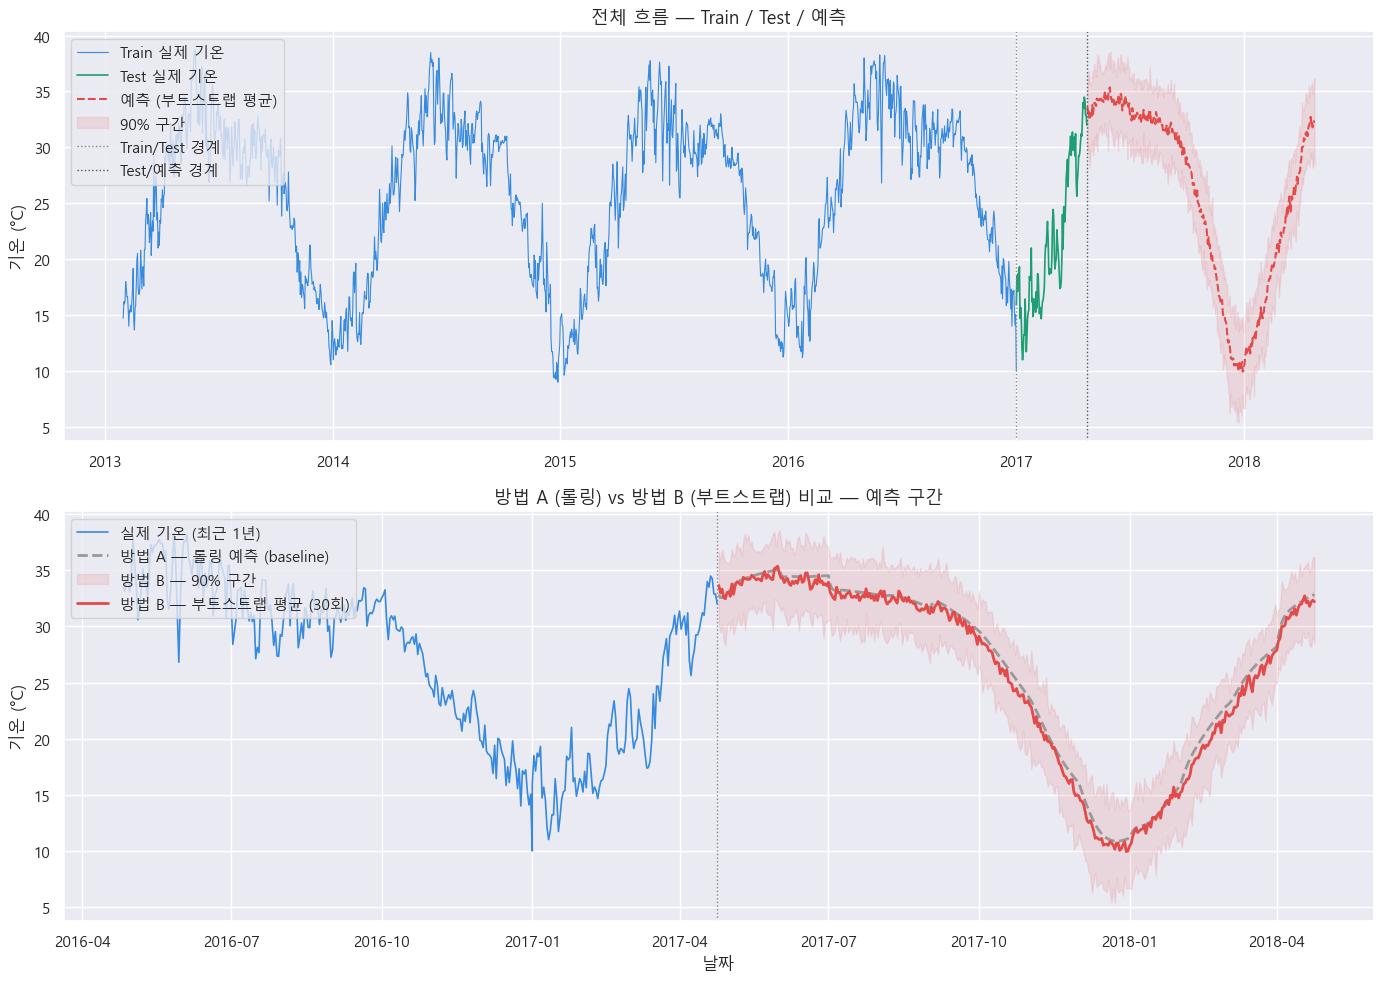

In [41]:
# ============================================================
# 7-4. 시각화
#    - 상단: Train + Test + 예측 전체 흐름
#    - 하단: 방법 A vs 방법 B 비교 (예측 구간만)
# ============================================================
# 전체 맥락(상단)과 예측 구간 상세(하단)를 분리해
# 거시적 흐름과 방법 간 차이를 동시에 파악

print("=" * 60)
print("7-4. 시각화")
print("=" * 60)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── [상단] 전체 흐름 (Train + Test + 예측)
axes[0].plot(df_model_tr['date'], df_model_tr['meantemp'],
             color='#378ADD', linewidth=0.8, label='Train 실제 기온')
axes[0].plot(df_model_te['date'], df_model_te['meantemp'],
             color='#1D9E75', linewidth=1.2, label='Test 실제 기온')
axes[0].plot(future_dates, pred_B_mean,
             color='#E24B4A', linewidth=1.5,
             linestyle='--', label='예측 (부트스트랩 평균)')                    # 30회 평균 예측선
axes[0].fill_between(future_dates, pred_B_lower, pred_B_upper,
                     color='#E24B4A', alpha=0.12, label='90% 구간')          # 불확실성 범위 음영
axes[0].axvline(df_model_te['date'].iloc[0],
                color='#888', linewidth=1.0,
                linestyle=':', label='Train/Test 경계')                        # 학습·평가 구간 구분선
axes[0].axvline(last_date, color='#555', linewidth=1.0,
                linestyle=':', label='Test/예측 경계')                         # 실제·예측 구간 구분선
axes[0].set_title('전체 흐름 — Train / Test / 예측', fontsize=13)
axes[0].set_ylabel('기온 (°C)')
axes[0].legend(loc='upper left')

# ── [하단] 예측 구간 확대 — 방법 A vs 방법 B
recent_df = all_temp.tail(365)                                                # 최근 1년 실제 기온 (맥락용)
axes[1].plot(recent_df['date'], recent_df['meantemp'],
             color='#378ADD', linewidth=1.2,
             label='실제 기온 (최근 1년)', zorder=5)
axes[1].axvline(last_date, color='#888', linewidth=1.0, linestyle=':')        # 예측 시작 기준선

# 방법 A
axes[1].plot(future_dates, pred_A,
             color='#999999', linewidth=2.0, linestyle='--',
             label='방법 A — 롤링 예측 (baseline)')                            # 단일 결정론적 예측선

# 방법 B
axes[1].fill_between(future_dates, pred_B_lower, pred_B_upper,
                     color='#E24B4A', alpha=0.12,
                     label='방법 B — 90% 구간')                               # 부트스트랩 불확실성 범위
axes[1].plot(future_dates, pred_B_mean, 
             color='#E24B4A', linewidth=2.0,
             label=f'방법 B — 부트스트랩 평균 ({N_BOOT}회)', zorder=5)         # 30개 시나리오 평균선

axes[1].set_title('방법 A (롤링) vs 방법 B (부트스트랩) 비교 — 예측 구간', fontsize=13)
axes[1].set_xlabel('날짜')
axes[1].set_ylabel('기온 (°C)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## <b>7-5. 월별 요약 + 최종 비교

In [42]:
# ============================================================
# 7-5. 월별 요약 + 최종 비교
# ============================================================
# 365일 예측을 월 단위로 집계해 계절 흐름을 한눈에 파악
# 두 방법의 1년 후 예측값을 나란히 비교해 최종 결론 도출

print("=" * 60)
print("7-5. 월별 예측 요약 (방법 B 기준)")
print("=" * 60)

df_pred = pd.DataFrame({
    'Date'           : future_dates,
    'Predicted_Temp' : pred_B_mean.round(2)                           # 방법 B 평균 예측값으로 구성
})
df_pred['YearMonth'] = df_pred['Date'].dt.to_period('M')              # 날짜를 연월(YearMonth) 단위로 변환

monthly = df_pred.groupby('YearMonth')['Predicted_Temp'].agg(
    평균='mean', 최고='max', 최저='min').round(2)                      # 월별 평균·최고·최저 집계
print(monthly.to_string(col_space=10))

df_pred.drop(columns='YearMonth').to_csv(                             # YearMonth 컬럼 제거 후 CSV 저장
    'delhi_future_prediction_1y.csv', index=False)                    # 인덱스 제외하고 저장
print("\n저장 완료 → 'delhi_future_prediction_1y.csv'")

print("\n" + "=" * 60)
print("최종 비교 요약")
print("=" * 60)
print(f"  마지막 실제 기온 ({last_date.date()}) : {last_actual:.2f}°C\n")
print(f"  {'방법':<30} {'1년후 예측':>10}  {'차이':>8}  {'하단':>10}  {'상단':>10}")
print("  " + "-" * 78)

rows = [
    ('A. 롤링 예측 (baseline)',   pred_A[-1],      None,             None),             # 방법 A: 단일 예측
    ('B. 부트스트랩 잔차 (평균)', pred_B_mean[-1], pred_B_lower[-1], pred_B_upper[-1]),  # 방법 B: 구간 포함
]
for name, mean, lo, hi in rows:                                        # 각 방법을 한 행씩 출력
    diff   = mean - last_actual                                        # 마지막 실제값 대비 변화량
    lo_str = f"{lo:.2f}°C" if lo is not None else "    —    "          # 구간 없는 방법은 — 표시
    hi_str = f"{hi:.2f}°C" if hi is not None else "    —    "
    print(f"  {name:<30} {mean:>9.2f}°C  {diff:>+7.2f}°C  {lo_str:>10}  {hi_str:>10}")

print()
print("※ 방법 B(부트스트랩)가 실제 변동성 패턴을 가장 현실적으로 반영합니다.")
print("※ 날씨 예측 특성상 계절 패턴은 잘 포착하나 단기 이상기후는 예측 어렵습니다.")

7-5. 월별 예측 요약 (방법 B 기준)
                   평균         최고         최저
YearMonth                                  
2017-04         33.01      33.65      32.46
2017-05         34.18      35.37      32.68
2017-06         34.05      34.77      33.30
2017-07         32.78      33.95      32.29
2017-08         32.23      33.18      31.26
2017-09         30.72      32.23      28.40
2017-10         25.98      29.13      23.19
2017-11         18.85      22.99      14.92
2017-12         11.49      14.89       9.94
2018-01         13.00      15.69      10.42
2018-02         18.78      21.66      15.18
2018-03         24.87      27.77      22.01
2018-04         31.10      32.73      27.88

저장 완료 → 'delhi_future_prediction_1y.csv'

최종 비교 요약
  마지막 실제 기온 (2017-04-24) : 32.00°C

  방법                                 1년후 예측        차이          하단          상단
  ------------------------------------------------------------------------------
  A. 롤링 예측 (baseline)                32.85°C    +0.85°C       —      